<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 50px;
  font-style: normal;
  background: linear-gradient(to right, #f6f5f2, #e8f0ef);
  letter-spacing: 3px;
  color: #fddf1c;
  border-radius: 10px;
  text-align: center;
  line-height: 1.2;
  padding: 20px 10px;
">
  ⚖️ <span>Storytelling with Data:</span><br>
  <span style="color: #f67738;"> Who Earns What? Gender 🧍‍♂️🧍‍♀️ Pay Realities on Glassdoor</span>
</h1>


<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 40px;
  font-weight: bold;
  background: linear-gradient(to right, #f6f5f2, #e8f0ef);
  letter-spacing: 3px;
  color: #47467b;
  border-radius: 10px;
  text-align: left;
  line-height: 1;
  padding: 5px 5px;
">
  <span>Introduction of the Dataset</span>
</h1>


<div style="
  font-family: 'Americana XBdCn BT' ;
  background: #f6f5f2;
  border-left: 8px solid #47467b;
  padding: 20px;
  margin: 20px auto;
  width: 95%;
  color: #333;
  font-size: 15px;
  border-radius: 10px;
  box-shadow: 2px 2px 10px rgba(0,0,0,0.05);
">
  <strong style="font-size: 25px; color: #47467b;">Context: 🧠</strong><br><br>
  The dataset has been sourced from <strong>Glassdoor</strong> and focuses on reported <strong>income data across various job titles</strong> segmented by <strong>gender</strong>.<br><br>
  Numerous studies have shown that <strong>women are often paid less than men</strong> for doing the same job.<br><br>
  This dataset enables a deeper exploration into the <strong>extent and patterns</strong> of the <strong>gender-based pay gap</strong> across different roles and industries.
</div>


<div style="
  font-family: 'Americana XBdCn BT';
  background: #f6f5f2;
  border-left: 8px solid #47467b;
  padding: 20px;
  margin: 20px auto;
  width: 95%;
  color: #333;
  font-size: 15px;
  border-radius: 10px;
  box-shadow: 2px 2px 10px rgba(0,0,0,0.05);
">
  <strong style="font-size: 25px; color: #47467b;">Attribute Information:</strong><br><br>
    
  1) <strong>Job Title</strong>: The employee’s role or designation in the company.<br>
    
  2) <strong>Gender</strong>: "Male", "Female", or "Other".<br>
  
  3) <strong>Age</strong>: Age of the employee in years.<br>
  
  4) <strong>PerfEval</strong>: Employee’s performance evaluation score or category.<br>
  
  5) <strong>Education</strong>: Highest education level attained (e.g., Bachelor's, Master's, PhD).<br>
  
  6) <strong>Dept</strong>: The department the employee belongs to (e.g., HR, IT, Finance).<br>
  
  7) <strong>Seniority</strong>: Rank or level indicating position in organizational hierarchy.<br>
  
  8) <strong>Base Pay</strong>: Annual fixed salary before bonuses.<br>
  
  9) <strong>Bonus</strong>: Additional variable compensation based on performance or other criteria.
</div>


<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 40px;
  font-weight: bold;
  background: linear-gradient(to right, #f6f5f2, #e8f0ef);
  letter-spacing: 3px;
  color: #47467b;
  border-radius: 10px;
  text-align: left;
  line-height: 1;
  padding: 5px 5px;
">
  <span>Let's start with the dataset.. Shall we....</span>
</h1>


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pywaffle import Waffle
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.transforms import Bbox
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker
from matplotlib import font_manager
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Glassdoor Gender Pay Gap.csv")

<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 40px;
  font-weight: bold;
  background: linear-gradient(to right, #f6f5f2, #e8f0ef);
  letter-spacing: 3px;
  color: #47467b;
  border-radius: 10px;
  text-align: left;
  line-height: 1;
  padding: 5px 5px;
">
  <span>Feature Engineering</span>
</h1>


In [3]:
df['AgeGroup'] = pd.cut(df['Age'],bins=[16, 24, 34, 44, 54, 65],labels=['17-24', '25-34', '35-44', '45-54', '55-65'])

df['SeniorityLevel'] = df['Seniority'].map({1: 'Entry',2: 'Junior',3: 'Mid',4: 'Senior',5: 'Executive'})

df['PerfCategory'] = pd.cut(df['PerfEval'], bins=[0, 1, 2, 3, 4, 5], labels=['Very Low','Low', 'Medium', 'High','Very High'], include_lowest=False)

df['BonusToBasePayRatio'] = (df['Bonus'] / df['BasePay']).round(2)

df1 = df[df["Gender"] == "Male"]
df2 = df[df["Gender"] == "Female"]

In [4]:
# main face color
facecolor = ["#f0f6f7"]
# for male colors     
colors1 = ['#fddf1c']
#for female colors
colors2 = ["#f67738"]
# ["#046d77"]
#fonts 
fonts = ["Americana XBdCn BT","Georgia"]

# titles and texts
accent = ["#613e3b",      #brown
          "#47467b"]     #lavender

In [5]:
def style_axes(ax, background_color):
    for a in ax:
        a.set_facecolor(background_color)
        a.set_yticks([])
        a.set_ylabel("")
        a.set_xlabel("")
        for spine in ["top", "right", "left"],"bottom":
            a.spines[spine].set_color(background_color)
        for label in a.get_xticklabels():
            label.set_fontname(fonts[1])
            label.set_fontsize(10)
            label.set_fontweight("semibold")
            

In [6]:
def add_title1(ax, fontsize, x_vals, y, labels, colors):
    for x, text, color in zip(x_vals, labels, colors):
        ax.text(x, y, text,transform=ax.transAxes,fontsize=fontsize,color=color,fontfamily=fonts[1],fontweight="bold")
def add_title2(ax, fontsize, x_vals, y_vals, labels, colors):
    for x, y, text, color in zip(x_vals, y_vals, labels, colors):
        ax.text(x, y, text, transform=ax.transAxes,
                fontsize=fontsize, color=color,
                fontfamily=fonts[0], fontweight="bold")


In [7]:
def set_spines_color1(ax, color):
    for spine in ['bottom', 'top', 'right', 'left']:
        ax.spines[spine].set_color(color)
def set_spines_color2(ax, color):
    for spine in ['bottom', 'top', 'right', 'left']:
        ax.spines[spine].set_color(color)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(axis='both', which='both', length=0)


<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 40px;
  font-weight: bold;
  background: linear-gradient(to right, #f6f5f2, #e8f0ef);
  letter-spacing: 3px;
  color: #47467b;
  border-radius: 10px;
  text-align: left;
  line-height: 1;
  padding: 5px 5px;
">
  <span>Visualization starts here...</span>
</h1>


In [8]:
df.head()

,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus,AgeGroup,SeniorityLevel,PerfCategory,BonusToBasePayRatio
0,Graphic Designer,Female,18,5,College,Operations,2,42363,9938,17-24,Junior,Very High,0.23
1,Software Engineer,Male,21,5,College,Management,5,108476,11128,17-24,Executive,Very High,0.10
2,Warehouse Associate,Female,19,4,PhD,Administration,5,90208,9268,17-24,Executive,High,0.10
3,Software Engineer,Male,20,5,Masters,Sales,4,108080,10154,17-24,Senior,Very High,0.09
4,Graphic Designer,Male,26,5,Masters,Engineering,5,99464,9319,25-34,Executive,Very High,0.09


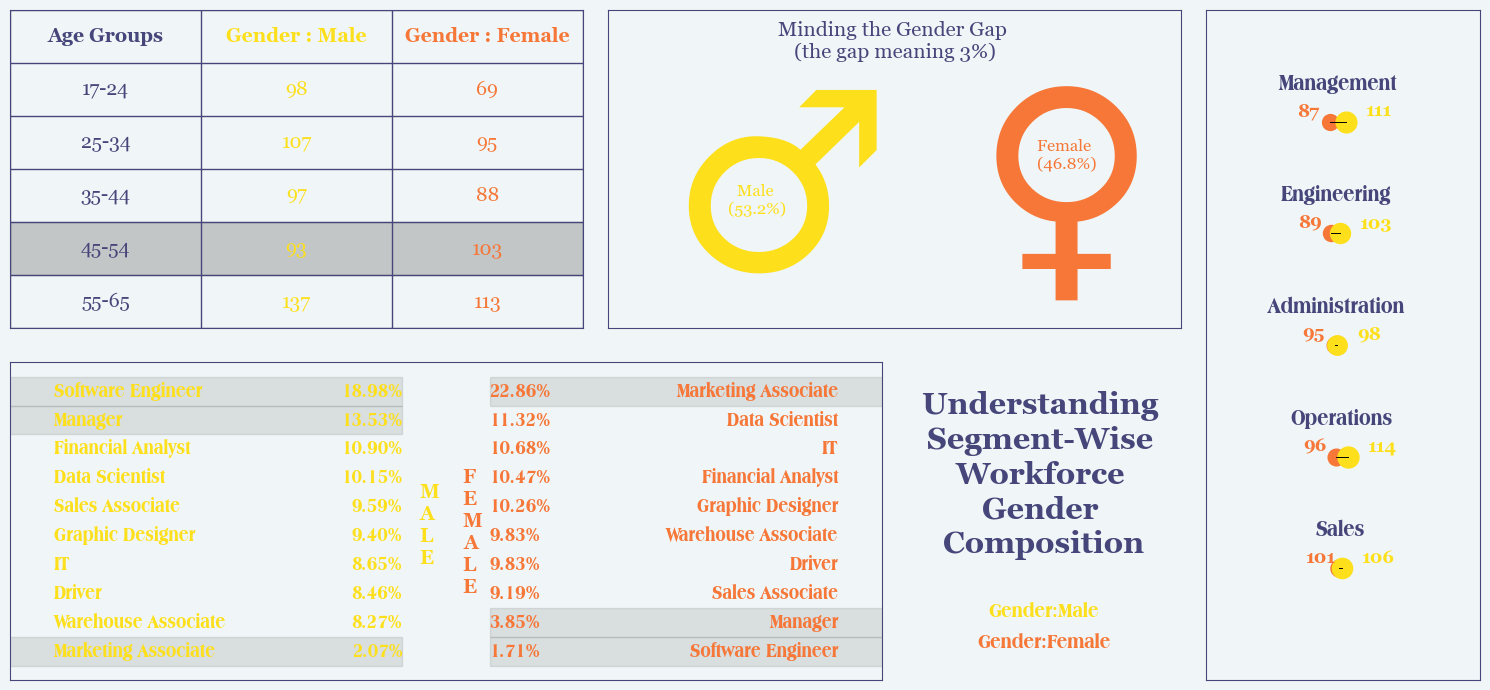

In [9]:
fig = plt.figure(figsize=(15, 7))
fig.patch.set_facecolor(facecolor[0]) 

ax = [None for _ in range(6)]
ax[0] = plt.subplot2grid((2, 5), (0, 2), colspan=2)  
ax[1] = plt.subplot2grid((2, 5), (0, 0), colspan=2)
ax[2] = plt.subplot2grid((2, 5), (1, 0), colspan=3)
ax[3] = plt.subplot2grid((2, 5), (0, 4), rowspan= 2)
ax[4] = plt.subplot2grid((2, 5), (1, 3), colspan=1)
# ------------------------------------------------------------Gender distribution plot
ax0= ax[0]
ax0.set_facecolor(facecolor[0])
ax0.set_xlim(0, 10)
ax0.set_ylim(0, 10)
# ax0.axis("off")
ax0.text(3, 4, "♂", fontsize=180, ha='center', va='center', color=colors1[0])
ax0.text(8, 4, "♀", fontsize=180, ha='center', va='center', color=colors2[0])
ax0.text(2.6, 3.6, "Male \n(53.2%)", fontsize=12, fontweight='normal', fontname=fonts[1], ha='center', color=colors1[0])
ax0.text(8, 5, "Female \n(46.8%)", fontsize=12, fontweight='normal', fontname=fonts[1], ha='center', color=colors2[0])
ax0.text(5, 8.5, "Minding the Gender Gap \n(the gap meaning 3%)", fontsize=15, fontweight='normal',ha="center", fontname=fonts[1], color=accent[1])
# ---------------------- PLOT FOR age groups ----------------------
n_rows, n_cols = 6, 3
ax1 = ax[1]
ax1.set_facecolor(facecolor[0])
ax1.set_xlim(0, n_cols)
ax1.set_ylim(0, n_rows)

for x in range(n_cols + 1):
    ax1.plot([x, x], [0, n_rows], color=accent[1], linewidth=1)
for y in range(n_rows + 1):
    ax1.plot([0, n_cols], [y, y], color=accent[1], linewidth=1)

age_groups = ['17-24', '25-34', '35-44', '45-54', '55-65']
ax1.text(0.5, 5.5, 'Age Groups', ha='center', va='center',fontsize=14, fontname=fonts[1], color=accent[1], weight='bold')
for i, group in enumerate(age_groups[::-1]):
    ax1.text(0.5, i + 0.5, group, ha='center', va='center',fontsize=14, fontname=fonts[1], color=accent[1])

genders = ['Male', 'Female']
counts = [
    [98, 107, 97, 93, 137],
    [69, 95, 88, 103, 113]
]
for col, gender, count_list, color in zip([1.5, 2.5], genders, counts, [colors1[0], colors2[0]]):
    ax1.text(col, 5.5, f'Gender : {gender}', ha='center', va='center',fontsize=14, fontname=fonts[1], color=color, weight='bold')
    for i, count in enumerate(count_list[::-1]):
        ax1.text(col, i + 0.5, str(count), ha='center', va='center',fontsize=14, fontname=fonts[1], color=color)

ax1.add_patch(Rectangle((0, 1), width=3, height=1, color="grey", alpha=0.4))

# ---------------------- job title distribution plot ----------------------
ax2 = ax[2]
ax2.set_facecolor(facecolor[0])

male_job_pct = df1['JobTitle'].value_counts(normalize=True).mul(100).sort_values(ascending=False)
female_job_pct = df2['JobTitle'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

# male_max, male_min = male_job_pct.max(), male_job_pct.min()
# female_max, female_min = female_job_pct.max(), female_job_pct.min()
#male 
for i, (title, pct) in enumerate(male_job_pct.items()):
    y = len(male_job_pct) - i - 1
    font_size = 14
    ax2.text(0.45, y, f"{pct:.2f}%", fontsize=font_size, fontname=fonts[0], fontweight='medium',color=colors1[0], ha='right', va='center')
    ax2.text(0.05, y, title, fontsize=font_size, fontname=fonts[0], fontweight='medium',color=colors1[0], ha='left', va='center')
# female
for i, (title, pct) in enumerate(female_job_pct.items()):
    y = len(female_job_pct) - i - 1
    font_size = 14
    ax2.text(0.55, y, f"{pct:.2f}%", fontsize=font_size, fontname=fonts[0], fontweight='medium',color=colors2[0], ha='left', va='center')
    ax2.text(0.95, y, title, fontsize=font_size, fontname=fonts[0], fontweight='medium',color=colors2[0], ha='right', va='center')
    # ax2.text(0.5, 5,"M \nA \nL \nE ", fontsize=14, fontname=fonts[0], fontweight='medium',color=colors1[0])

highlights = [
    {'x': -0.05, 'y_vals': [len(male_job_pct) - i - 1 for i in range(2)]},{'x': 0.55, 'y_vals': [i for i in range(2)]},
    {'x': -0.05, 'y_vals': [0]},{'x': 0.55, 'y_vals': [len(female_job_pct) - 1]}]

for h in highlights:
    for y in h['y_vals']:
        ax2.add_patch(Rectangle((h['x'], y - 0.5), 0.5, 1, color='grey', alpha=0.2))

ax2.set_xlim(0, 1)
ax2.set_ylim(-1, max(len(male_job_pct), len(female_job_pct)))

# ---------------------- dept distibution plot ----------------------

ax3 = ax[3]
ax[3].set_facecolor(facecolor[0])
female_counts = df2['Dept'].value_counts()
male_counts = df1['Dept'].value_counts().reindex(female_counts.index)

y_labels = list(female_counts.index)
y_pos = list(range(len(y_labels)))

# counts on the dots
for i, dept in enumerate(y_labels):
    x_female = female_counts[dept]
    x_male = male_counts[dept]
    y = y_pos[i]
    ax3.plot([x_female, x_male], [y, y], color='black', linewidth=0.7)
    ax3.scatter(x_female, y, s=x_female * 1.5, color=colors2[0], alpha=1)
    ax3.text(x_female - 50, y + 0.05, f"{x_female}", fontdict={'font': fonts[1], 'fontsize': 13, 'weight': 'bold', 'color': colors2[0]})
    ax3.scatter(x_male, y, s=x_male * 2, color=colors1[0], alpha=1)
    ax3.text(x_male + 30, y + 0.05, f"{x_male}", fontdict={'font': fonts[1], 'fontsize': 13, 'weight': 'bold', 'color': colors1[0]})
#department names
for i, dept in enumerate(y_labels):
    x_female = female_counts[dept]
    x_male = male_counts[dept]
    x_mid = (x_female + x_male) / 2
    ax3.text(x_mid, i + 0.25, dept, fontdict={'font': fonts[0], 'fontsize': 16, 'weight': 'semibold', 'color': accent[1]},ha='center', va='bottom')

ax3.set_xlim(xmin=-100, xmax=max(male_counts.max(), female_counts.max()) + 200)
ax3.set_ylim(ymin=-1, ymax=len(y_labels))
ax3.set_yticks([])
ax3.set_xticks([])

# ---------------------- main heading ----------------------
ax4 = ax[4]
ax4.set_facecolor(facecolor[0])
ax4.text(0.5, 0.4, "Understanding \nSegment-Wise \nWorkforce \nGender \nComposition", fontsize=22,ha="center", color=accent[1], fontweight="bold", font=fonts[1])
ax4.text(0.5, 0.2, "Gender:Male", fontsize=15, color=colors1[0], fontweight="normal", font=fonts[0],ha="center")
ax4.text(0.5, 0.1, "Gender:Female", fontsize=15, color=colors2[0], fontweight="normal", font=fonts[0],ha="center")
ax2.text(0.47, 3,"M \nA \nL \nE ", fontsize=14, fontname=fonts[1], fontweight='bold',color=colors1[0])
ax2.text(0.52, 2,"F \nE \nM \nA \nL \nE ", fontsize=14, fontname=fonts[1], fontweight='bold',color=colors2[0])
set_spines_color2(ax0, accent[1])
set_spines_color2(ax1, accent[1])
set_spines_color2(ax2, accent[1])
set_spines_color2(ax3, accent[1])
set_spines_color2(ax4, facecolor[0])
fig.subplots_adjust(wspace=0.05, hspace=0.05)
fig.tight_layout()
plt.show()


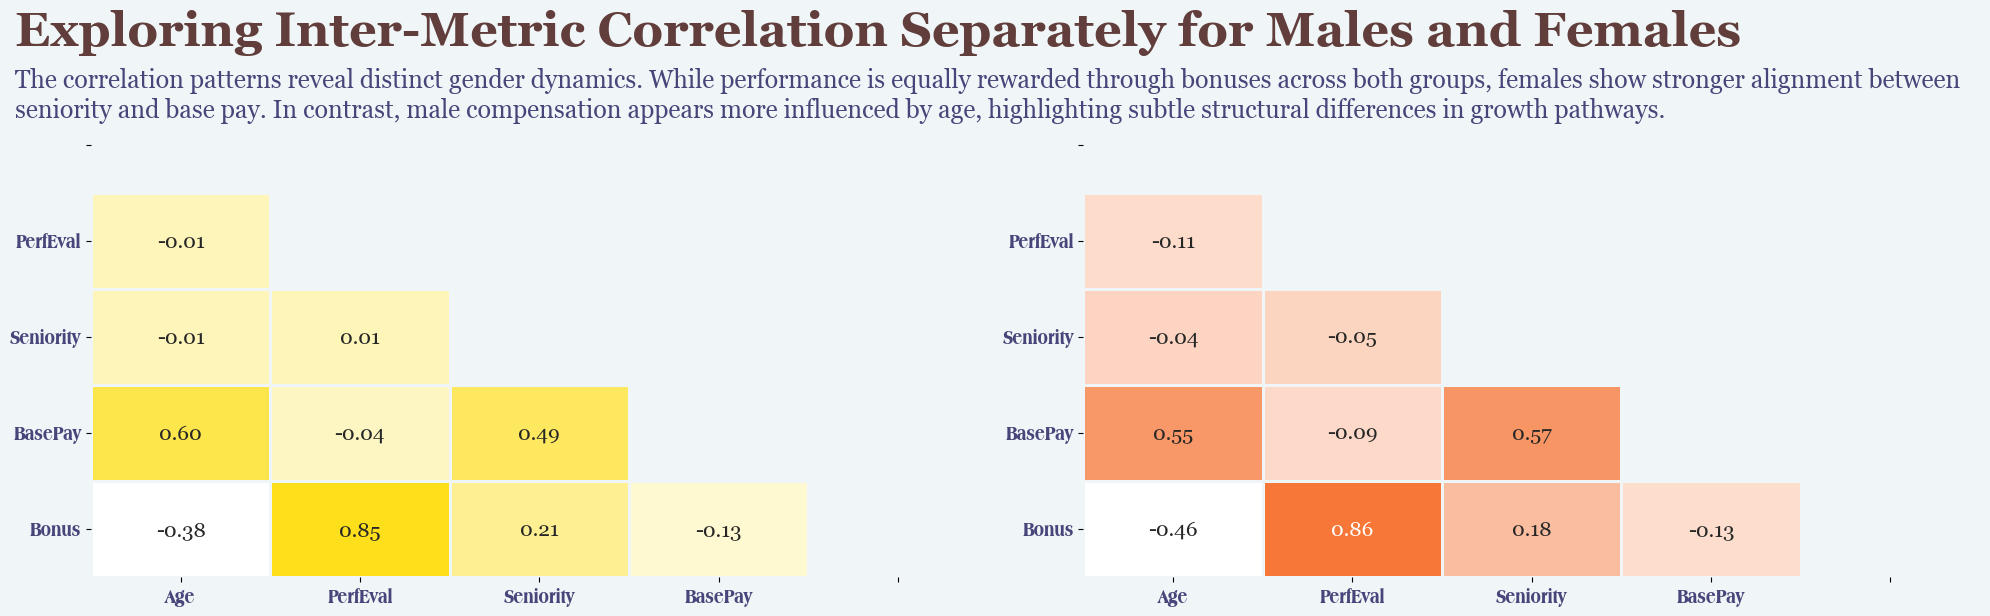

In [10]:
num_df1 = df1.select_dtypes("int64")
num_df2 = df2.select_dtypes("int64")

corr1 = num_df1.corr()
corr2 = num_df2.corr()

male_cmap = LinearSegmentedColormap.from_list("male_cmap", ["white", colors1[0]])
female_cmap = LinearSegmentedColormap.from_list("female_cmap", ["white", colors2[0]])

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 6), facecolor=facecolor[0])
ax1.set_facecolor(facecolor[0])
ax2.set_facecolor(facecolor[0])

fig.suptitle("Exploring Inter-Metric Correlation Separately for Males and Females", fontsize=35, color=accent[0], fontweight='bold', font=fonts[1],x=0.01,y=1.02,ha='left')

fig.text(0.01, 0.84,"""The correlation patterns reveal distinct gender dynamics. While performance is equally rewarded through bonuses across both groups, females show stronger alignment between 
seniority and base pay. In contrast, male compensation appears more influenced by age, highlighting subtle structural differences in growth pathways."""
,fontsize=18, ha='left',font=fonts[1], fontweight="medium",color=accent[1])

mask1 = np.triu(np.ones_like(corr1, dtype=bool))
mask2 = np.triu(np.ones_like(corr2, dtype=bool))

sns.heatmap(corr1, mask=mask1, annot=True, fmt=".2f", cmap=male_cmap, cbar=False, ax=ax1,linewidth=1, linecolor=facecolor[0],annot_kws={'font': 'serif', 'size': 15, 'font':fonts[1]})
sns.heatmap(corr2, mask=mask2, annot=True, fmt=".2f", cmap=female_cmap, cbar=False, ax=ax2,linewidth=1, linecolor=facecolor[0],annot_kws={'font': 'serif', 'size': 15, 'font':fonts[1]})
xticks = ['Age', 'PerfEval','Seniority', 'BasePay','']
yticks = ['', 'PerfEval','Seniority', 'BasePay','Bonus']
ax1.set_xticklabels(xticks, fontname=fonts[0], fontsize=14, weight='bold', rotation=0,color=accent[1])
ax1.set_yticklabels(yticks, fontname=fonts[0], fontsize=14, weight='bold', rotation=0,color=accent[1])
ax2.set_xticklabels(xticks, fontname=fonts[0], fontsize=14, weight='bold', rotation=0,color=accent[1])
ax2.set_yticklabels(yticks, fontname=fonts[0], fontsize=14, weight='bold', rotation=0,color=accent[1])
plt.tight_layout()
plt.show()


<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 40px;
  font-weight: bold;
  background: linear-gradient(to right, #f6f5f2, #e8f0ef);
  letter-spacing: 3px;
  color: #47467b;
  border-radius: 10px;
  text-align: left;
  line-height: 1;
  padding: 5px 5px;
">
  <span>Job Titles Analysis: Cross-Department Role Classification and Hierarchical Distribution</span>
</h1>


In [11]:
# job titles
# - percentage distribution of genders in each job title
# - percentage distribution of genders comparison wrt to titles
# - basepay violinplot distribution of genders wrt titles
# - heatmap to show which gender win at each dept and title with how much average
# -kde distribution of basepay wrt to job titles at each seniority level


In [12]:
gender_counts = df.groupby(['JobTitle', 'Gender']).size().unstack(fill_value=0)
gender_counts['Total'] = gender_counts.sum(axis=1)
gender_counts['Female%'] = ((gender_counts.get('Female', 0) / gender_counts['Total']) * 100).round(1)
gender_counts['Male%'] = ((gender_counts.get('Male', 0) / gender_counts['Total']) * 100).round(1)
df_gender = gender_counts[['Female%', 'Male%']].reset_index()

In [13]:
def draw_gender_composition_bar(ax, job, gap_line):
    row = df_gender[df_gender['JobTitle'] == job].iloc[0]
    female_percent = row['Female%']
    male_percent = row['Male%']
    gap = round(abs(female_percent - male_percent), 2)
    ax.patch.set_facecolor(facecolor[0])
    x_female, x_male = 0.5,1.0
    # Female bar
    ax.bar(x_female, female_percent, width=0.3, color=colors2[0], label='Female',edgecolor="black",linewidth=2)
    ax.text(x_female, female_percent + 2, f"{female_percent:.1f}%", ha='center', va='bottom',fontdict={'font': fonts[1], 'weight': 'bold', 'color': colors2[0], 'fontsize': 13})

    # Male bar
    ax.bar(x_male, male_percent, width=0.3, color=colors1[0], label='Male',edgecolor="black",linewidth=2)
    ax.text(x_male, male_percent + 2, f"{male_percent:.1f}%", ha='center', va='bottom',fontdict={'font': fonts[1], 'weight': 'bold', 'color': colors1[0], 'fontsize': 13})
    # Title
    ax.text(0.75, 95, job.upper(), ha="center",fontdict={'font': fonts[0], 'size': 15, 'color': accent[0], 'weight': 'bold'})
    # Gap sentence
    ax.text(0.75, 80, f"{gap_line} ({gap}%)", ha="center", va="center",fontdict={'font': fonts[0], 'size': 14, 'color': accent[1], 'weight': 'bold'})
    # gender names 
    ax.text(1.2,30,"M \nA \nL \nE ", fontsize=14, fontname=fonts[1], fontweight='bold',color=colors1[0])
    ax.text(0.2,20,"F \nE \nM \nA \nL \nE ", fontsize=14, fontname=fonts[1], fontweight='bold',color=colors2[0])
    # Clean up
    ax.set_ylim(0, 110)
    ax.set_xlim(0.2, 1.3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

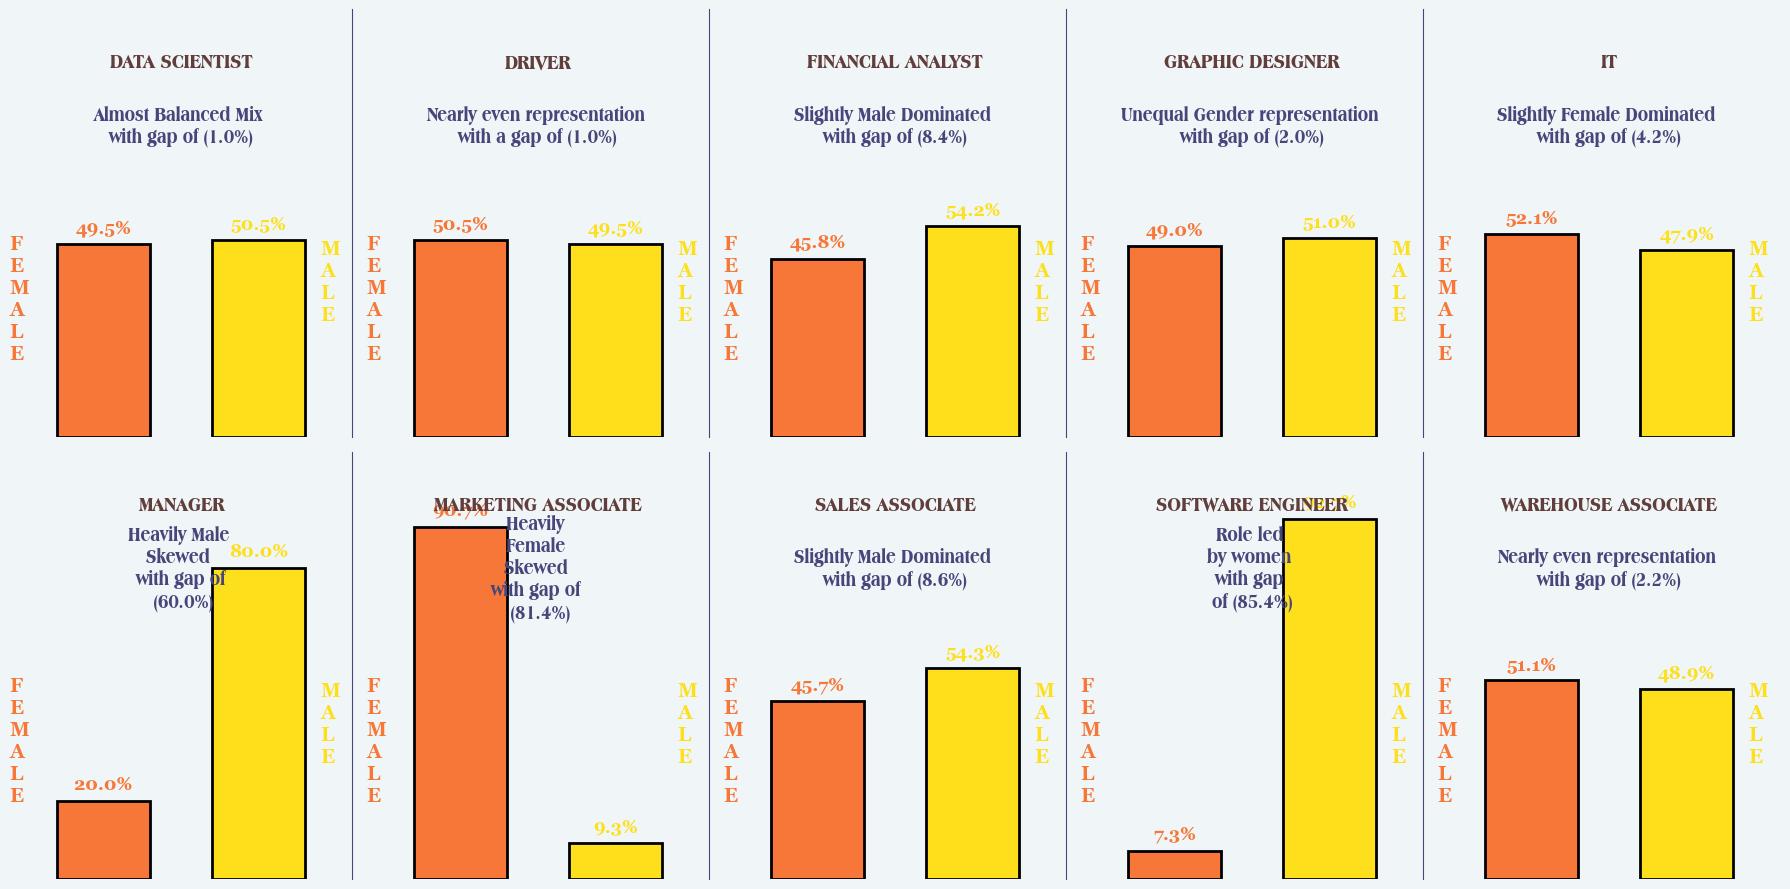

In [14]:
fig = plt.figure(figsize=(18, 9))
fig.patch.set_facecolor(facecolor[0])
ax1 = plt.subplot2grid((2, 5), (0, 0))
draw_gender_composition_bar(ax1, "Data Scientist", "Almost Balanced Mix \nwith gap of")

ax2 = plt.subplot2grid((2, 5), (0, 1))
draw_gender_composition_bar(ax2, "Driver", "Nearly even representation \nwith a gap of")

ax3 = plt.subplot2grid((2, 5), (0, 2))
draw_gender_composition_bar(ax3, "Financial Analyst", "Slightly Male Dominated \nwith gap of")

ax4 = plt.subplot2grid((2, 5), (0, 3))
draw_gender_composition_bar(ax4, "Graphic Designer", "Unequal Gender representation \nwith gap of")

ax5 = plt.subplot2grid((2, 5), (0, 4))
draw_gender_composition_bar(ax5, "IT", "Slightly Female Dominated \nwith gap of")

ax6 = plt.subplot2grid((2, 5), (1, 0))
draw_gender_composition_bar(ax6, "Manager", "Heavily Male \nSkewed \nwith gap of\n")

ax7 = plt.subplot2grid((2, 5), (1, 1))
draw_gender_composition_bar(ax7, "Marketing Associate", "Heavily \nFemale \nSkewed \nwith gap of \n")

ax8 = plt.subplot2grid((2, 5), (1, 2))
draw_gender_composition_bar(ax8, "Sales Associate", "Slightly Male Dominated \nwith gap of")

ax9 = plt.subplot2grid((2, 5), (1, 3))
draw_gender_composition_bar(ax9, "Software Engineer", "Role led \nby women \nwith gap \nof")

ax10 = plt.subplot2grid((2, 5), (1, 4))
draw_gender_composition_bar(ax10, "Warehouse Associate", "Nearly even representation \nwith gap of")
show_spine = [ax1, ax2, ax3, ax4, ax6, ax7, ax8, ax9]

for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]:
    if ax in show_spine:
        ax.spines['right'].set(color=accent[1], visible=True)
        [ax.spines[side].set_visible(False) for side in ['top', 'left', 'bottom']]
    else:
        [ax.spines[side].set_visible(False) for side in ['top', 'left', 'bottom', 'right']]

fig.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout()
plt.show()


In [15]:
data = df.groupby(["JobTitle", "Gender"]).agg(mean_basepay=("BasePay", "mean"),count=("BasePay", "count")).round({'mean_basepay': 0}).reset_index()
data['mean_basepay'] = data['mean_basepay'].astype(int).apply(lambda x: f"{x // 1000}k")

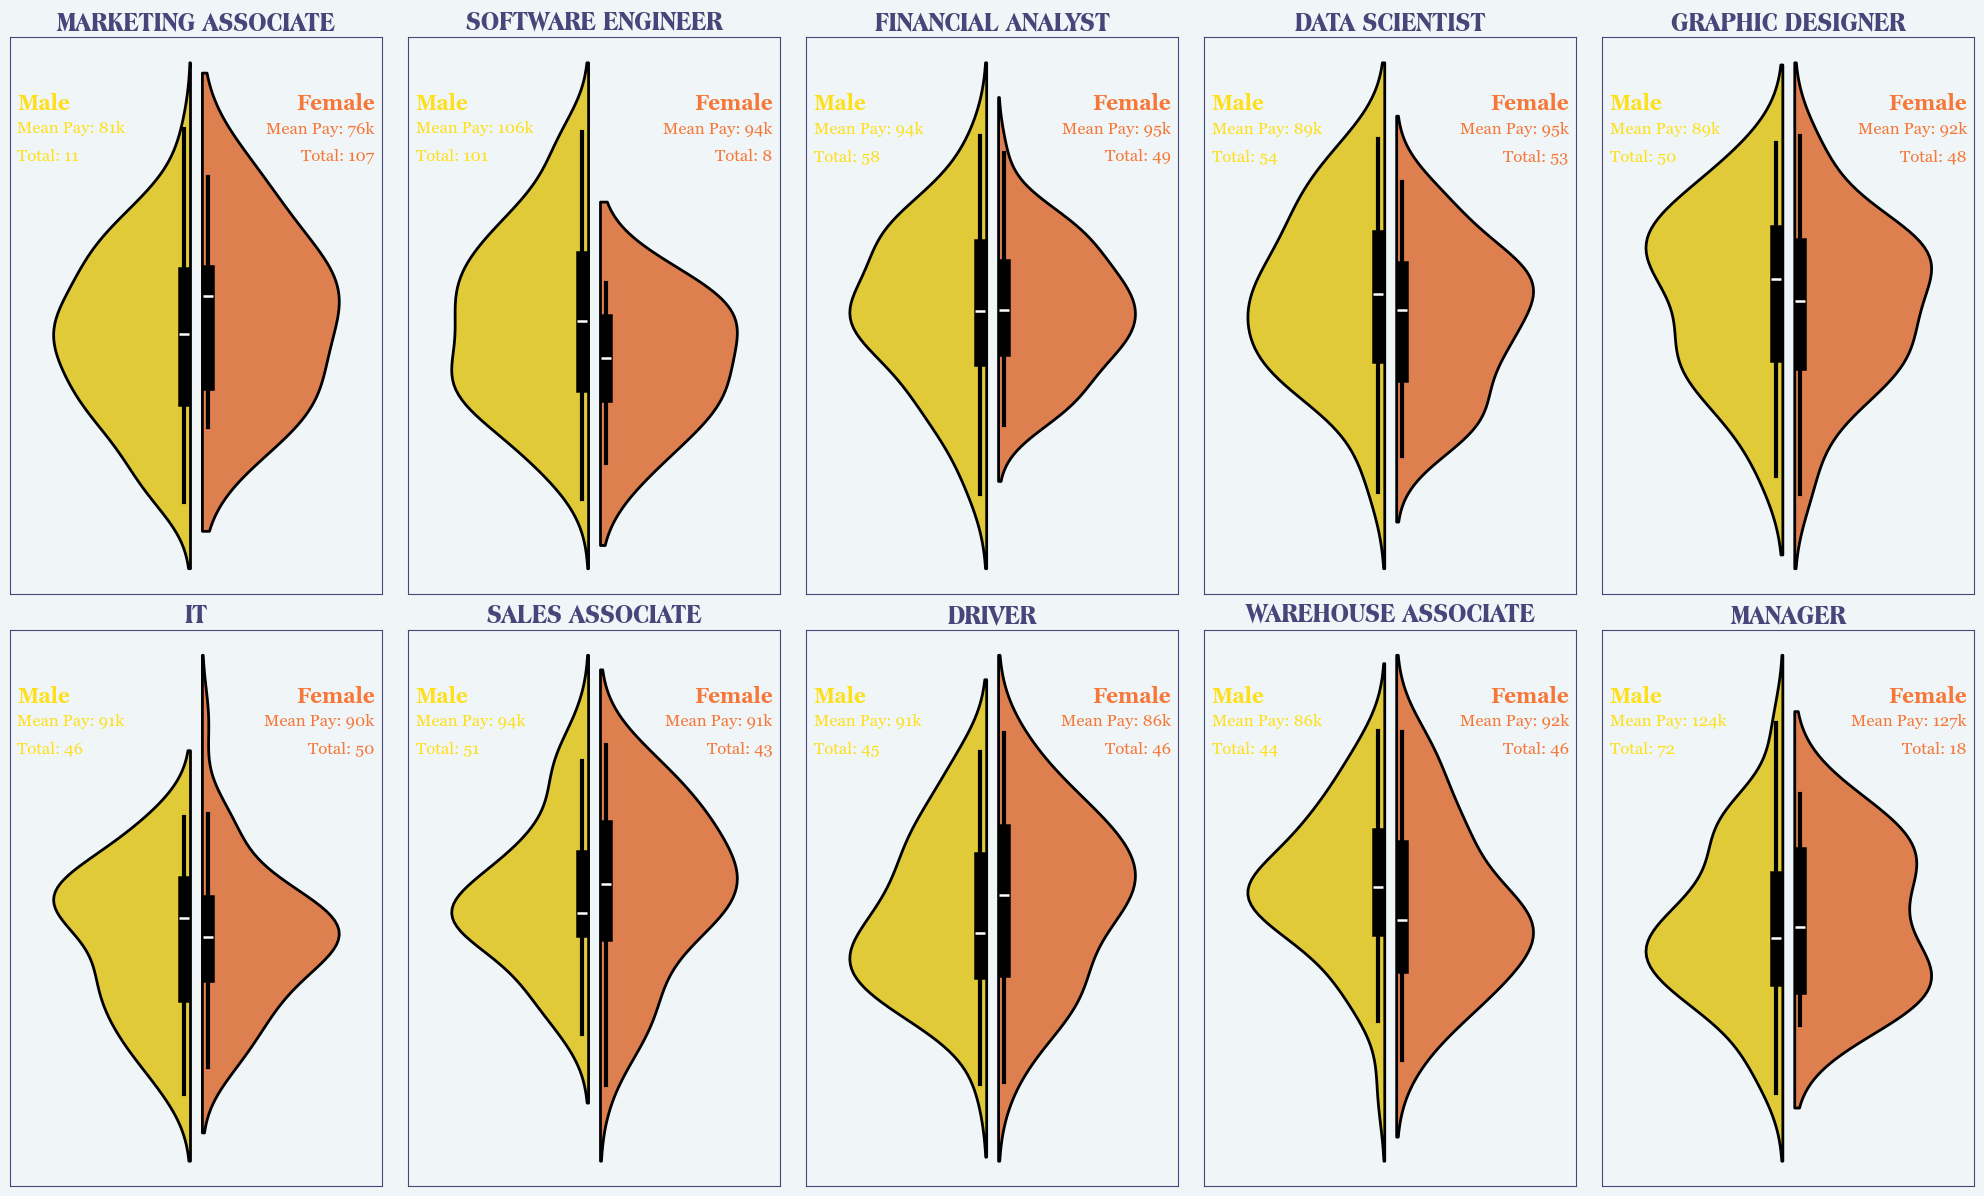

In [16]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(facecolor[0])

# 10 job titles for layout
titles = ['Marketing Associate', 'Software Engineer', 'Financial Analyst',
          'Data Scientist', 'Graphic Designer', 'IT', 'Sales Associate', 'Driver',
          'Warehouse Associate', 'Manager']

# Define 2x5 subplot grid positions
positions = [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4),
             (1, 0), (1, 1), (1, 2), (1, 3), (1, 4)]

for i, title in enumerate(titles):
    ax = plt.subplot2grid((2, 5), positions[i])
    ax.set_facecolor(facecolor[0])

    subset = df[df["JobTitle"] == title]
    ax.axes.get_yaxis().set_visible(False)
    sns.violinplot(y=subset["BasePay"], hue=subset["Gender"], split=True,palette=[colors1[0], colors2[0]], ax=ax, alpha=1,linewidth=2, linecolor="k",gap=0.08,edgecolor="black")
    ax.text(0.5, 1.05, title.upper(), transform=ax.transAxes, ha="center", va="top",fontdict={'font': fonts[0], 'size': 20, 'color': accent[1], 'weight': 'bold'})
    ax.legend().set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    set_spines_color1(ax, accent[1])
    # Extract stats from your gender-summary dataframe
    male_stats = data[(data["JobTitle"] == title) & (data["Gender"] == "Male")]
    female_stats = data[(data["JobTitle"] == title) & (data["Gender"] == "Female")]
    
    # Left side (Male)
    ax.text(0.02, 0.90, "Male", transform=ax.transAxes, ha="left", va="top",fontdict={'font': fonts[1], 'size': 15, 'weight': 'bold', 'color': colors1[0]})
    ax.text(0.02, 0.85, f"Mean Pay: {male_stats['mean_basepay'].values[0]}", transform=ax.transAxes,ha="left", va="top", fontdict={'font': fonts[1], 'size': 12, 'color': colors1[0]})
    ax.text(0.02, 0.8, f"Total: {male_stats['count'].values[0]}", transform=ax.transAxes,ha="left", va="top", fontdict={'font': fonts[1], 'size': 12, 'color': colors1[0]})    
    # Right side (Female)
    ax.text(0.98, 0.90, "Female", transform=ax.transAxes, ha="right", va="top",fontdict={'font': fonts[1], 'size': 15, 'weight': 'bold', 'color': colors2[0]})
    ax.text(0.98, 0.85, f"Mean Pay: {female_stats['mean_basepay'].values[0]}", transform=ax.transAxes,ha="right", va="top", fontdict={'font': fonts[1], 'size': 12, 'color': colors2[0]})
    ax.text(0.98, 0.8, f"Total: {female_stats['count'].values[0]}", transform=ax.transAxes,ha="right", va="top", fontdict={'font': fonts[1], 'size': 12, 'color': colors2[0]})
plt.tight_layout()
plt.show()


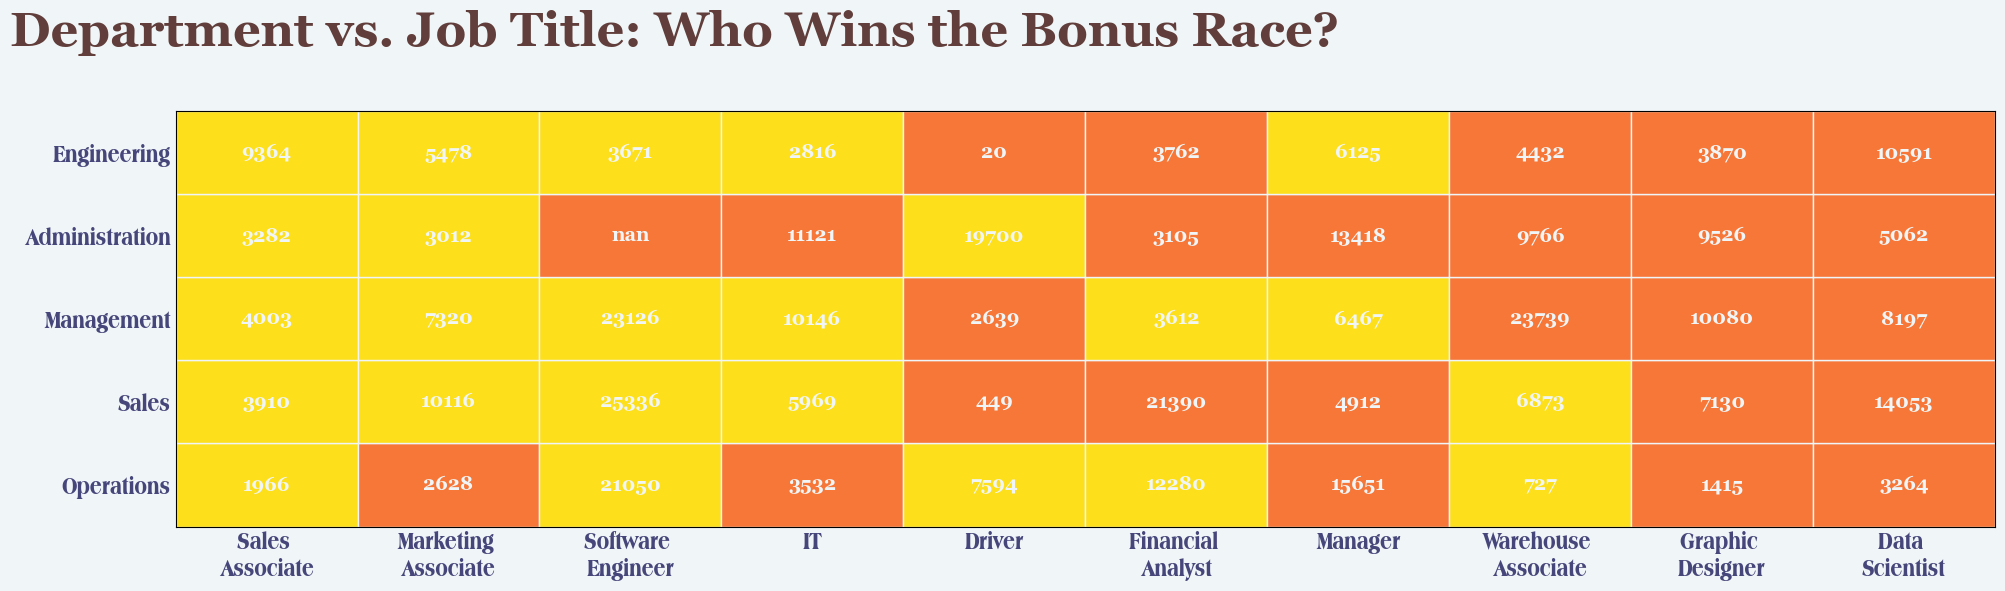

In [17]:
grouped = df.groupby(['Dept', 'JobTitle', 'Gender'])['BasePay'].mean().reset_index()
table = (grouped.pivot(index=['Dept', 'JobTitle'], columns='Gender', values='BasePay').reset_index())
for g in ['Male', 'Female']:
    if g not in table.columns:
        table[g] = 0
table['Winner'] = table.apply(lambda x: 'Male' if x['Male'] > x['Female'] else 'Female', axis=1)
table['Gap'] = abs(table['Male'] - table['Female'])
fig, ax = plt.subplots(figsize=(20, 5))
fig.patch.set_facecolor(facecolor[0])
ax.set_facecolor(facecolor[0])
color_map = {'Male': colors1[0], 'Female': colors2[0]}
job_titles = ["Sales Associate","Marketing Associate","Software Engineer","IT","Driver",
              "Financial Analyst","Manager","Warehouse Associate","Graphic Designer",'Data Scientist']
depts = df['Dept'].value_counts().index.tolist()
for i, dept in enumerate(depts):
    for j, job in enumerate(job_titles):
        row = table[(table['Dept'] == dept) & (table['JobTitle'] == job)]
        if not row.empty:
            winner = row['Winner'].values[0]
            gap = row['Gap'].values[0]
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=color_map[winner], ec=facecolor[0]))
            ax.text(j + 0.5, i + 0.5, f"{gap:.0f}",ha='center', va='center',fontproperties=fonts[1], color=facecolor[0], fontsize=14, fontweight="bold")
        else:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=facecolor[0], ec=accent[1], alpha=0.3))

ax.set_xticks([x + 0.5 for x in range(len(job_titles))])
ax.set_yticks([y + 0.5 for y in range(len(depts))])
titles = ["Sales \nAssociate","Marketing \nAssociate","Software \nEngineer","IT","Driver",
              "Financial \nAnalyst","Manager","Warehouse \nAssociate","Graphic \nDesigner",'Data \nScientist']

ax.set_xticklabels(titles, rotation=0, ha='center', fontproperties=fonts[0], color=accent[1],fontsize=17,fontweight="bold")
ax.set_yticklabels(depts, fontproperties=fonts[0], color=accent[1],fontsize=17,fontweight="bold")

ax.invert_yaxis()
ax.set_xlim(0, len(job_titles))
ax.set_ylim(0, len(depts))
ax.tick_params(axis='both', length=0)
fig.text(0.0, 1.1,"Department vs. Job Title: Who Wins the Bonus Race?",fontproperties=fonts[1],color=accent[0],fontsize=35,fontweight="bold")
ax.grid(False)
plt.tight_layout()
plt.show()


In [18]:
gender_counts = (df.groupby(["SeniorityLevel", "JobTitle", "Gender"]).size().unstack(fill_value=0))
gender_percent = (gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100).round(1)
gender_percent = gender_percent.rename(columns={"Female": "Female", "Male": "Male"}).reset_index()
level_gender= gender_percent.sort_values(by=["SeniorityLevel", "Female"], ascending=[True, False]).reset_index(drop=True)
level_gender.head()

Gender,SeniorityLevel,JobTitle,Female,Male
0,Entry,Marketing Associate,92.0,8.0
1,Entry,Driver,66.7,33.3
2,Entry,Data Scientist,55.6,44.4
3,Entry,IT,42.9,57.1
4,Entry,Graphic Designer,42.1,57.9


In [19]:
def plot_gender_by_level(data, level):
    gender_percent = data[data['SeniorityLevel'] == level]
    fig, ax = plt.subplots(figsize=(20, 6), facecolor=facecolor[0])
    ax.patch.set_facecolor(facecolor[0])
    ax.bar(gender_percent["JobTitle"],gender_percent["Female"],label="Female",width = 0.5,color=colors2[0],edgecolor="black",linewidth=2)
    # Male bars (stacked on top of female)
    ax.bar(gender_percent["JobTitle"],gender_percent["Male"],bottom=gender_percent["Female"],width = 0.3,label="Male",color=colors1[0],edgecolor="black",linewidth=2)
    ax.set_ylim(0, 100)
    ax.set_yticks([ 25, 50, 75, 100])
    ax.set_yticklabels([f"{x}%" for x in [25, 50, 75, 100]],fontdict={'font': fonts[1], 'color': accent[1], 'size': 15, 'weight': 'bold'})
    ax.set_ylabel("")
    ax.text(0.5, 1.3, f"LEVEL: {level.upper()}", fontsize=30, fontweight="semibold",font=fonts[1],color=accent[0], ha="center", transform=ax.transAxes)
    job_titles_wrapped = [title.replace(" ", "\n") for title in gender_percent["JobTitle"]]
    ax.set_xticks(range(len(gender_percent["JobTitle"])))
    ax.set_xticklabels(job_titles_wrapped,rotation=0,ha="center",fontdict={'font': fonts[0], 'color': accent[1], 'weight': 'bold', 'size': 16})
    add_title1(ax=ax,fontsize=25,x_vals=[0.44, 0.5, 0.52],y=1.1,labels=["Male","|","Female"],colors=[colors1[0], "black", colors2[0]])
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(accent[1])

    plt.tight_layout()
    plt.show()


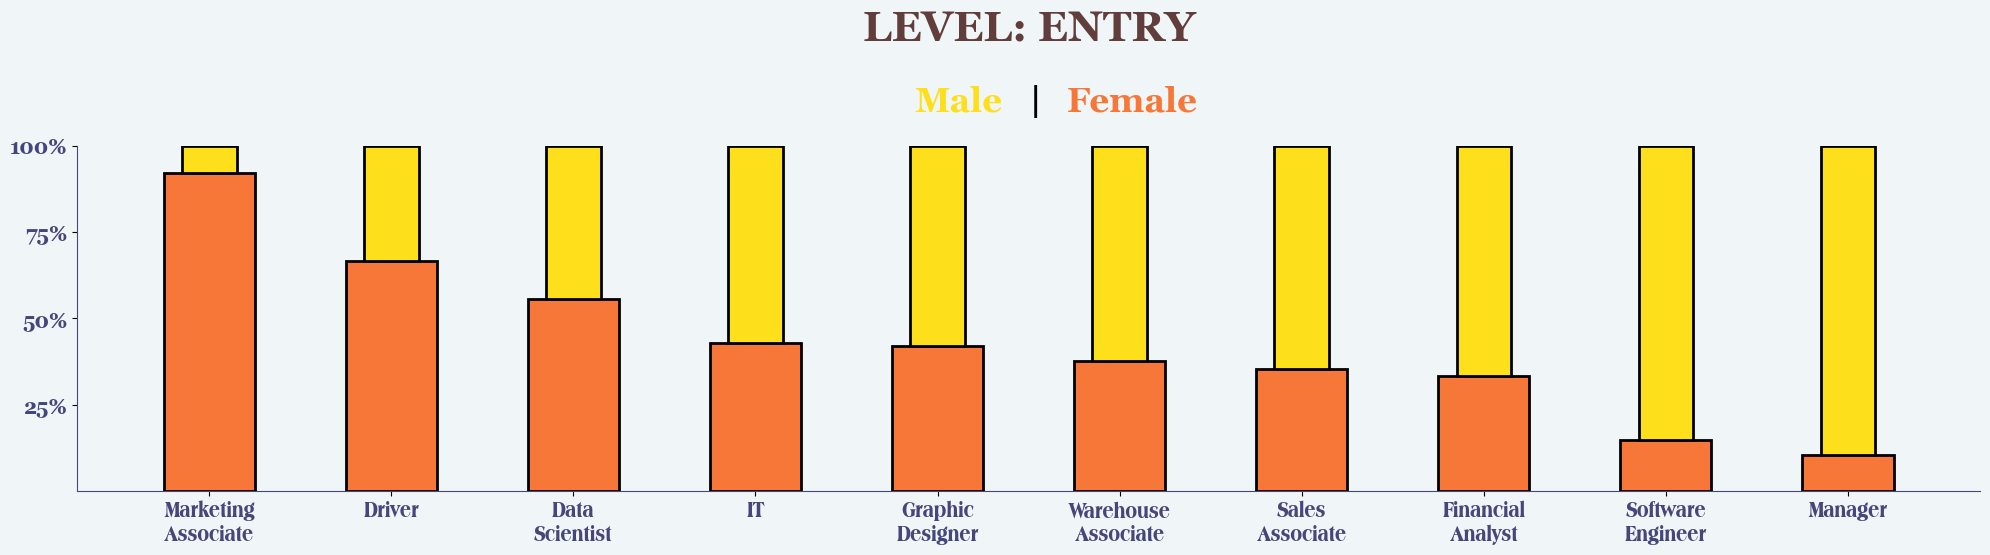

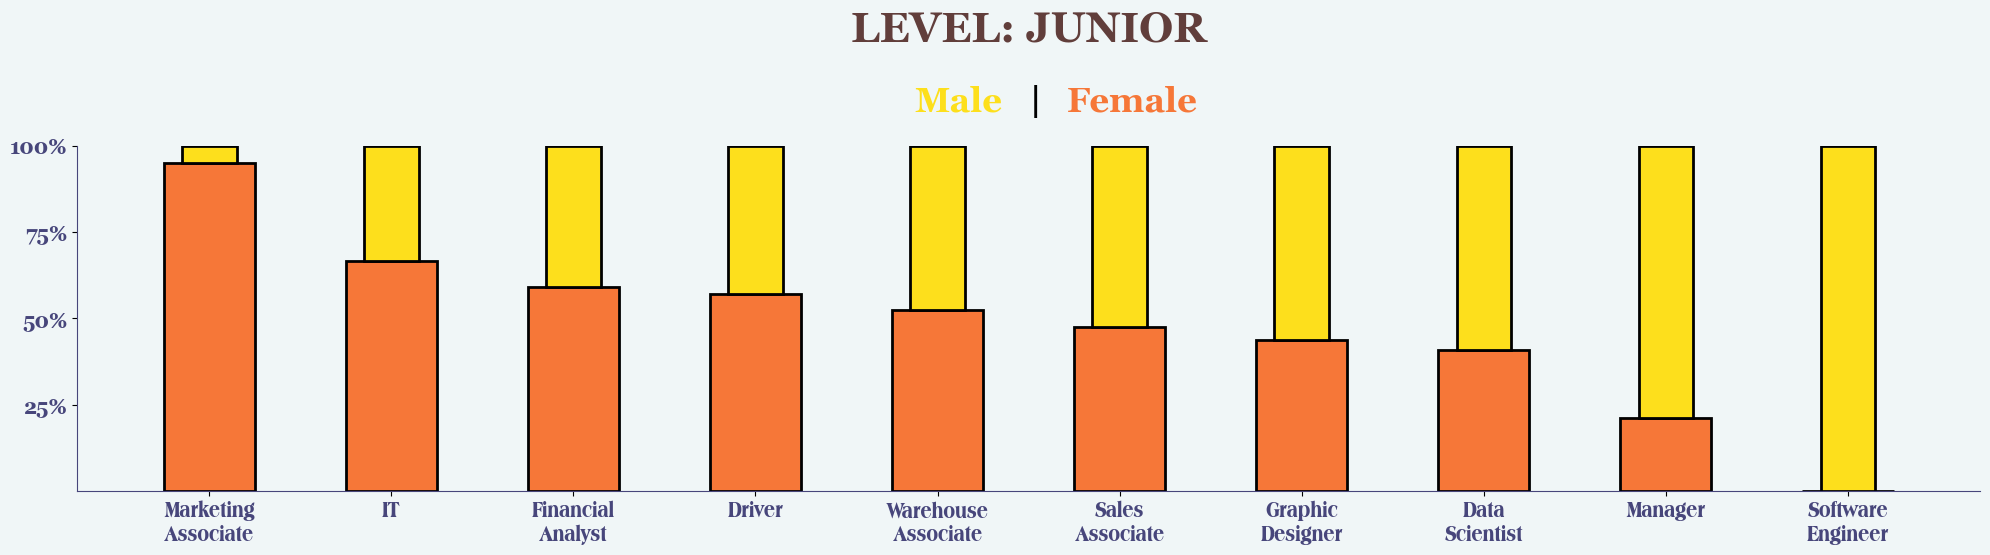

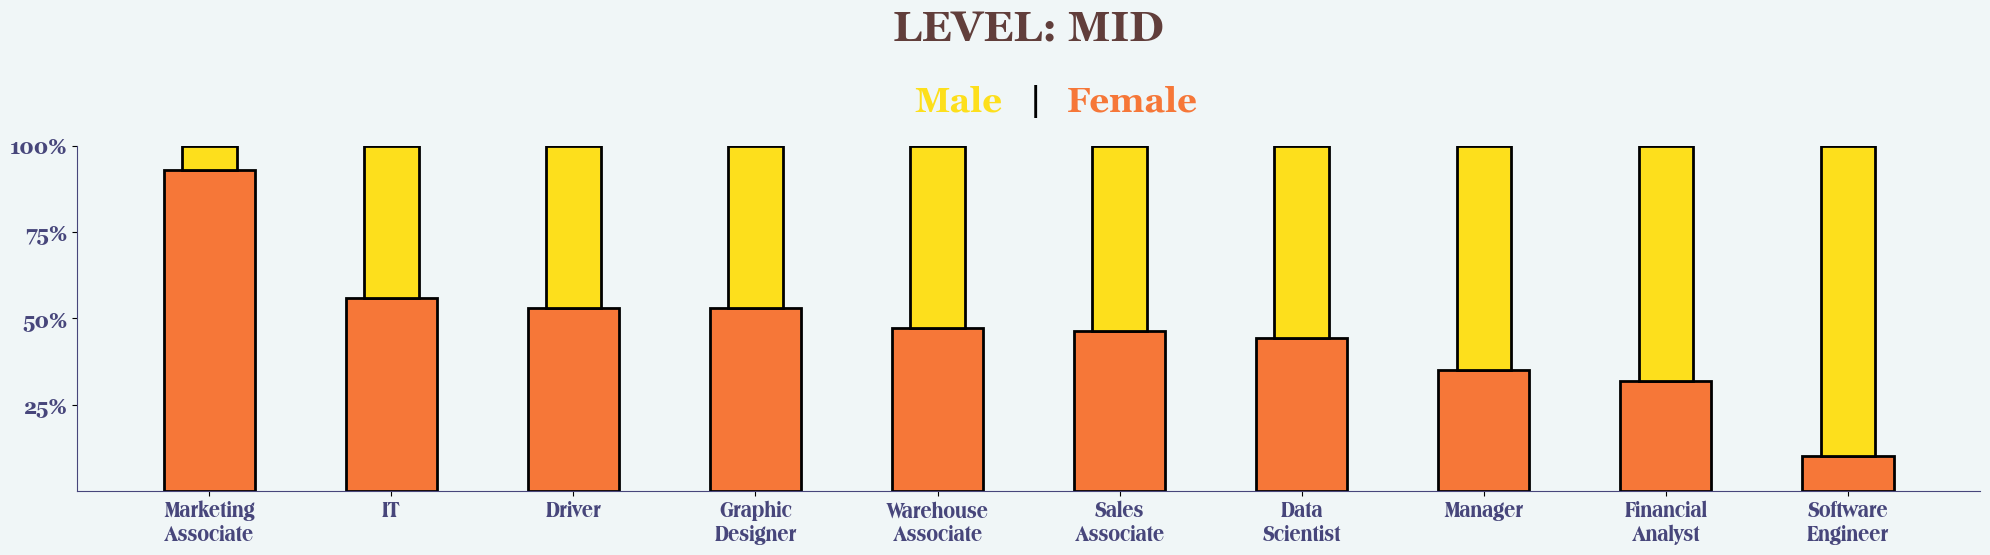

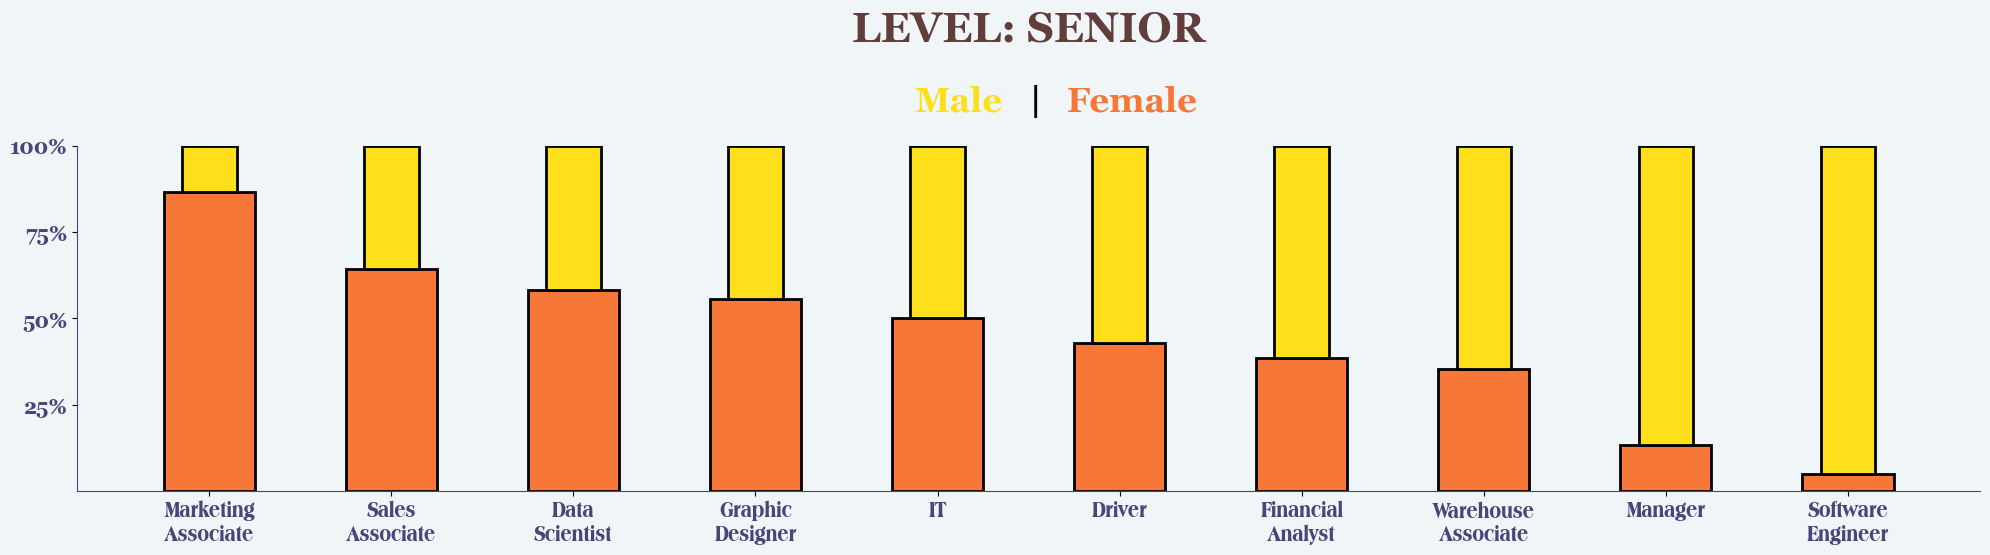

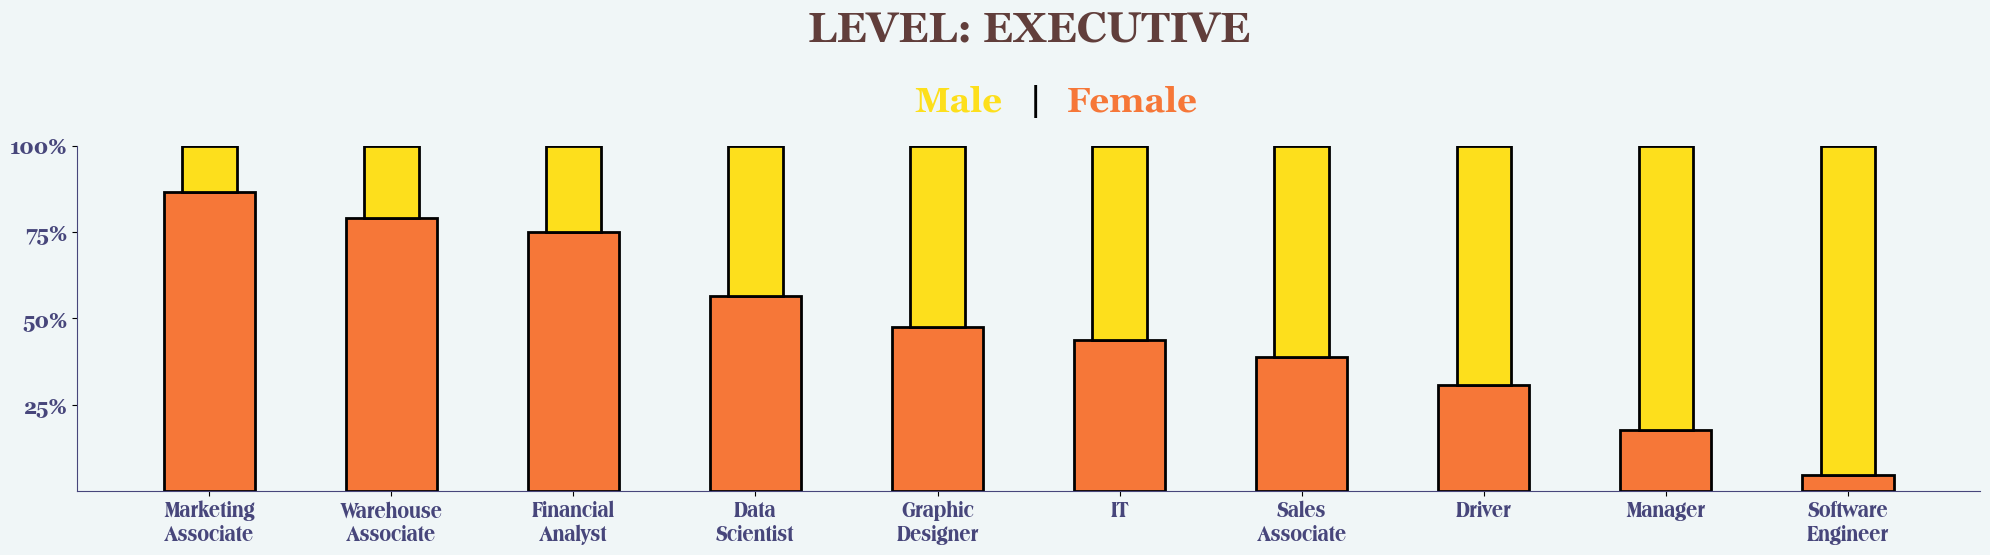

In [20]:
plot_gender_by_level(level_gender, "Entry")
plot_gender_by_level(level_gender, "Junior")
plot_gender_by_level(level_gender, "Mid")
plot_gender_by_level(level_gender, "Senior")
plot_gender_by_level(level_gender, "Executive")

In [21]:
def plot_kde_by_job(job_title):
    levels = ["Entry", "Junior", "Mid", "Senior", "Executive"]
    fig = plt.figure(figsize=(25, 5), dpi=200)
    fig.patch.set_facecolor(facecolor[0])
    fig.suptitle(f"{job_title} Salary Distribution by Seniority Level", fontsize=30,fontweight="semibold", font=fonts[1], color=accent[0], y=1.05)
    for i, level in enumerate(levels):
        ax = plt.subplot2grid((1, 5), (0, i))
        ax.set_facecolor(facecolor[0])
        data = df[(df["JobTitle"] == job_title) & (df["SeniorityLevel"] == level)]
        sns.kdeplot(data=data[data["Gender"] == "Male"], x='BasePay', fill=True, alpha=0.7,color=colors1[0], ax=ax, linewidth=3, ec='black')
        sns.kdeplot(data=data[data["Gender"] == "Female"], x='BasePay', fill=True, alpha=0.8,color=colors2[0], ax=ax, linewidth=3, ec='black')
        ax.text(0.5, 1.09, f"Level: {level}", transform=ax.transAxes, ha="center", va="top",fontdict={'font': fonts[0], 'size': 22, 'color': accent[1], 'weight': 'bold'})
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        set_spines_color1(ax, facecolor[0]) 
    plt.tight_layout()
    plt.show()

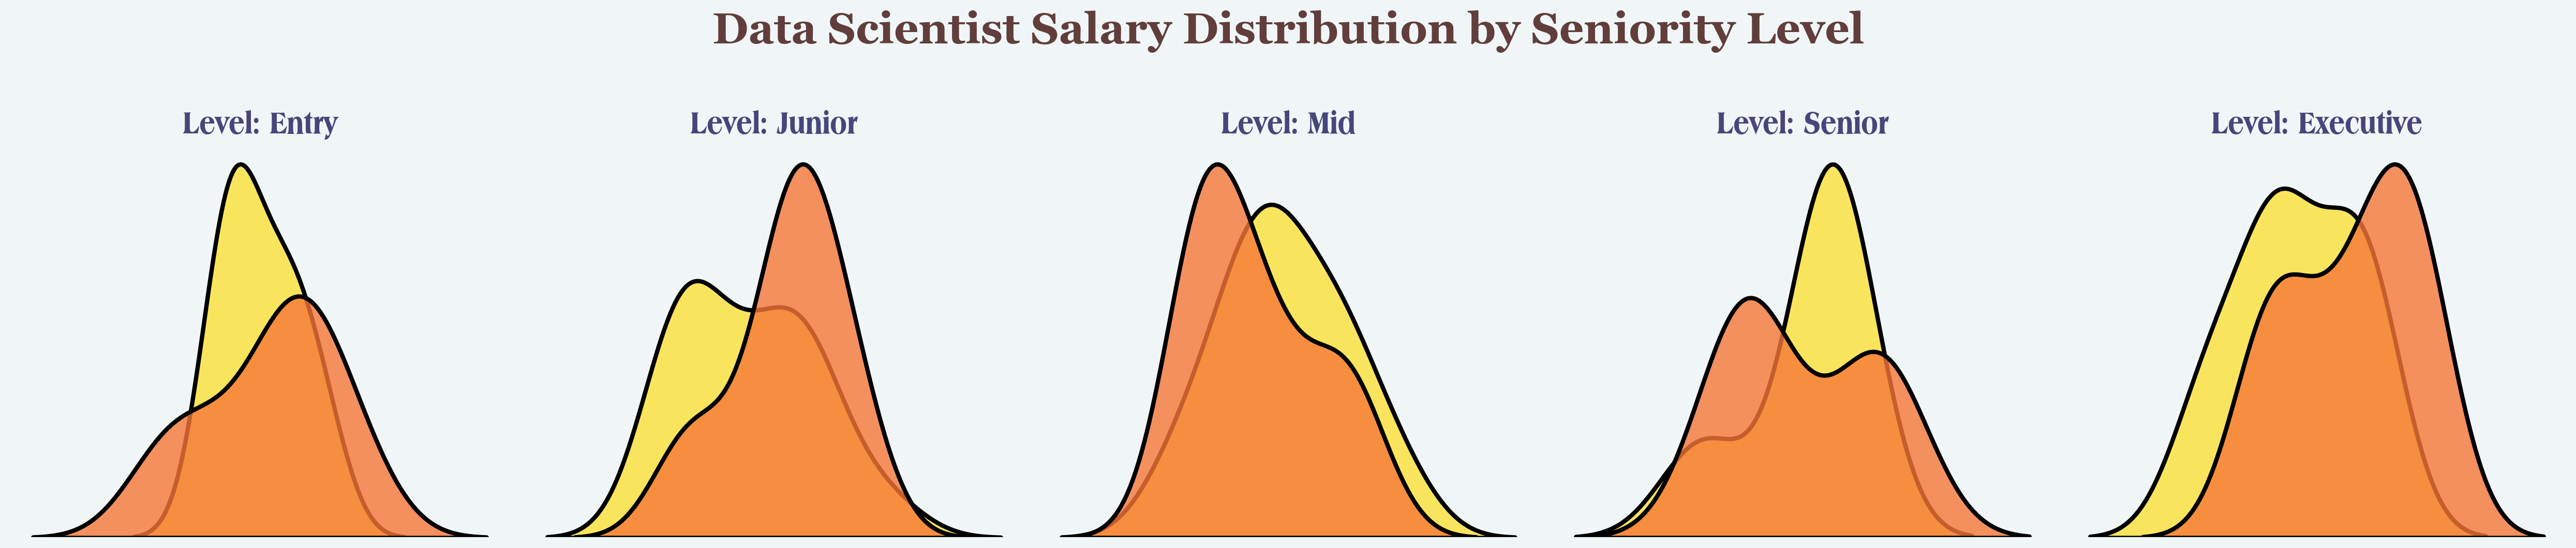

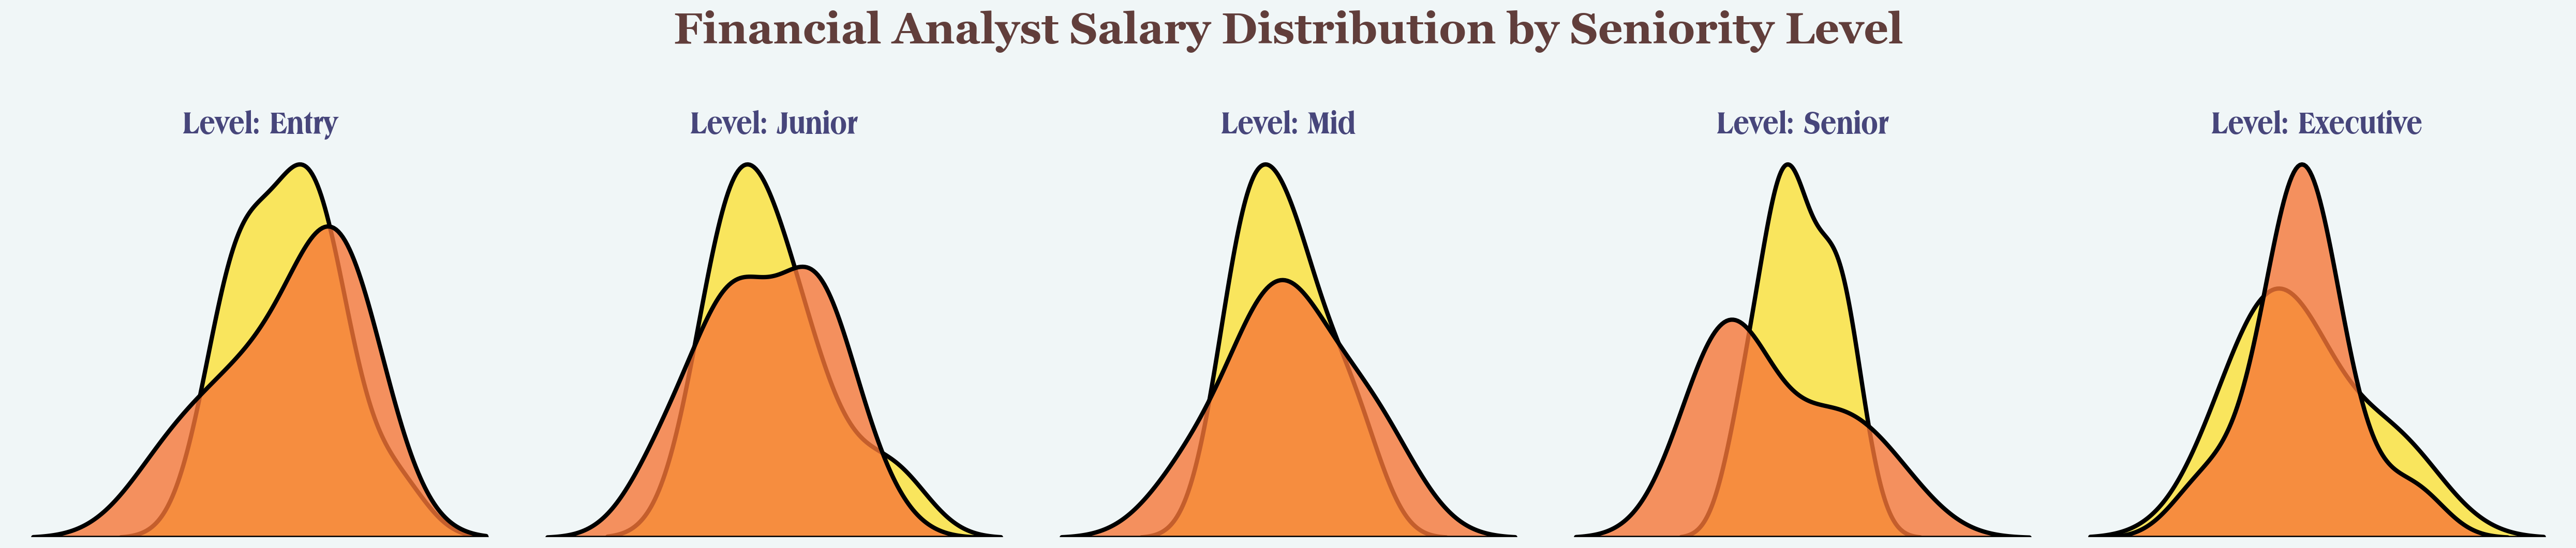

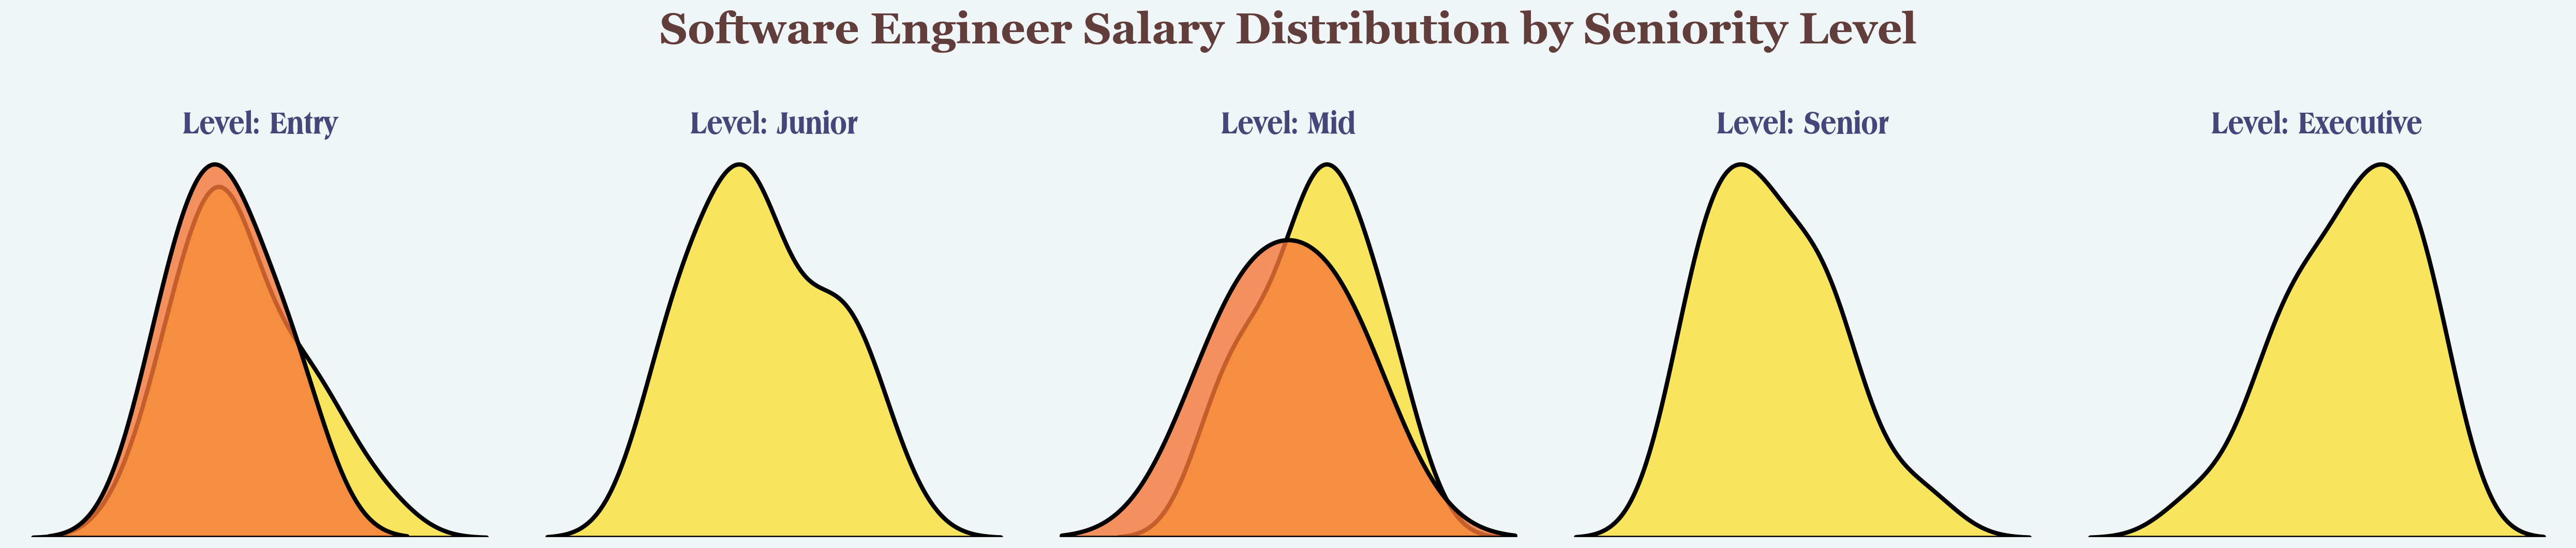

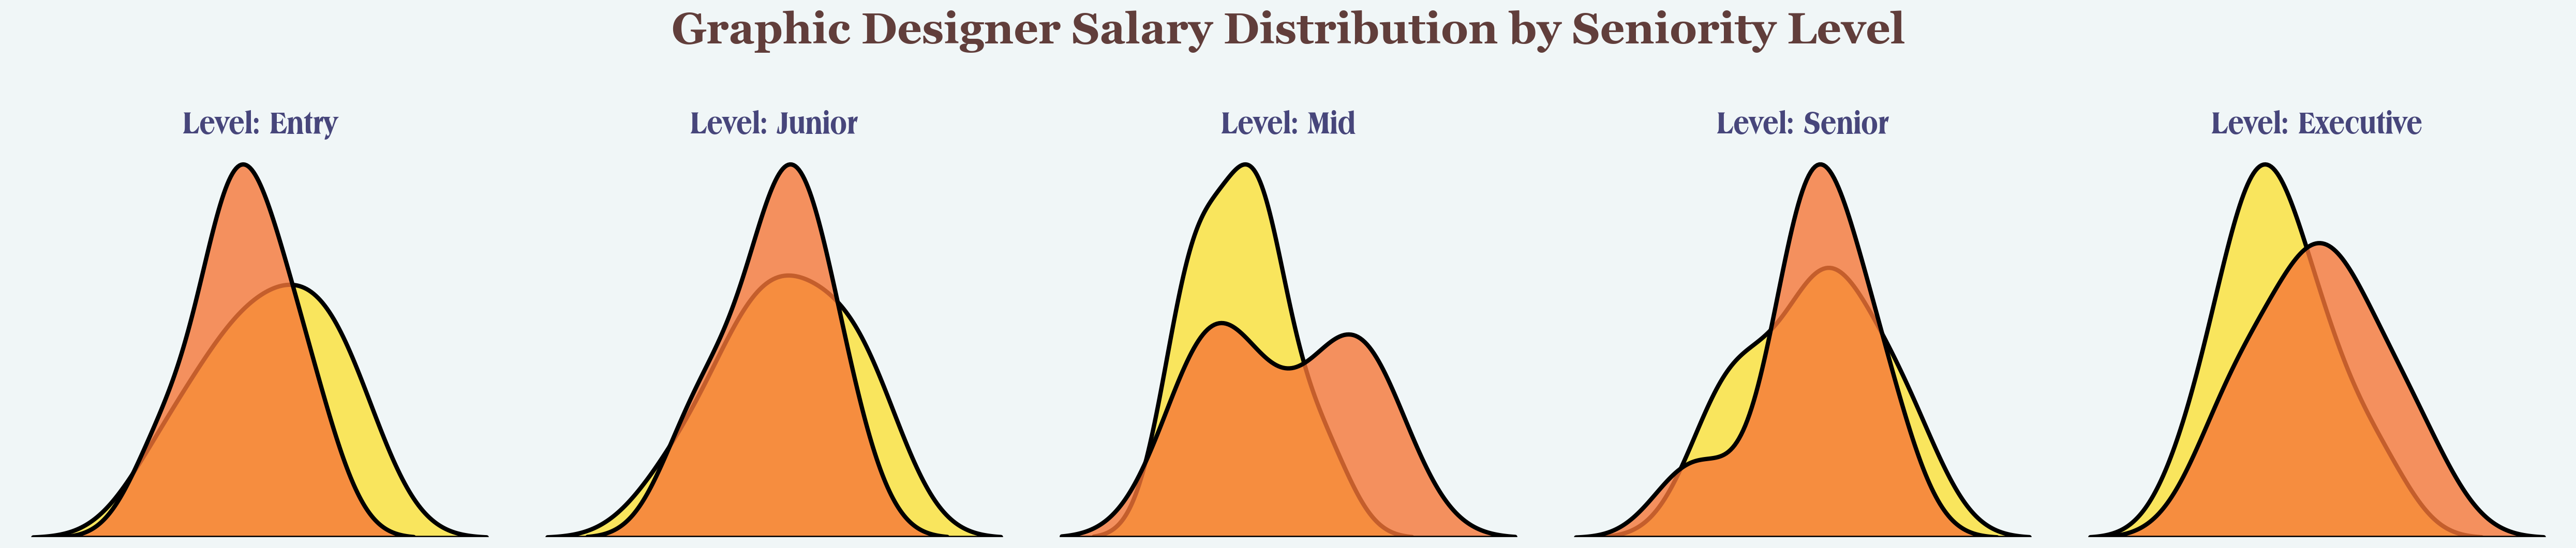

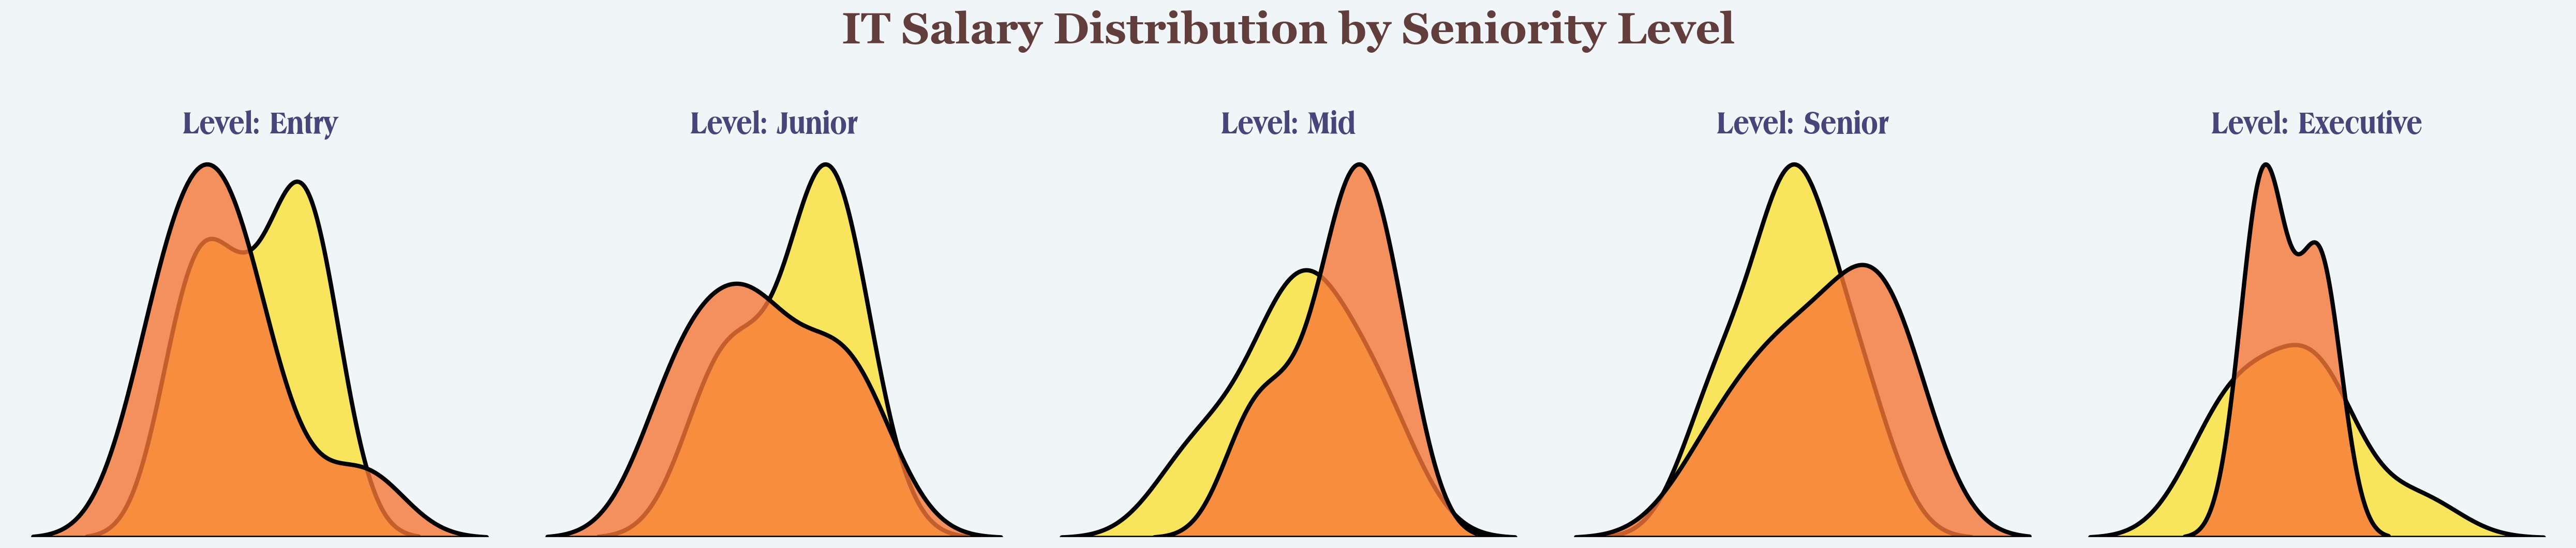

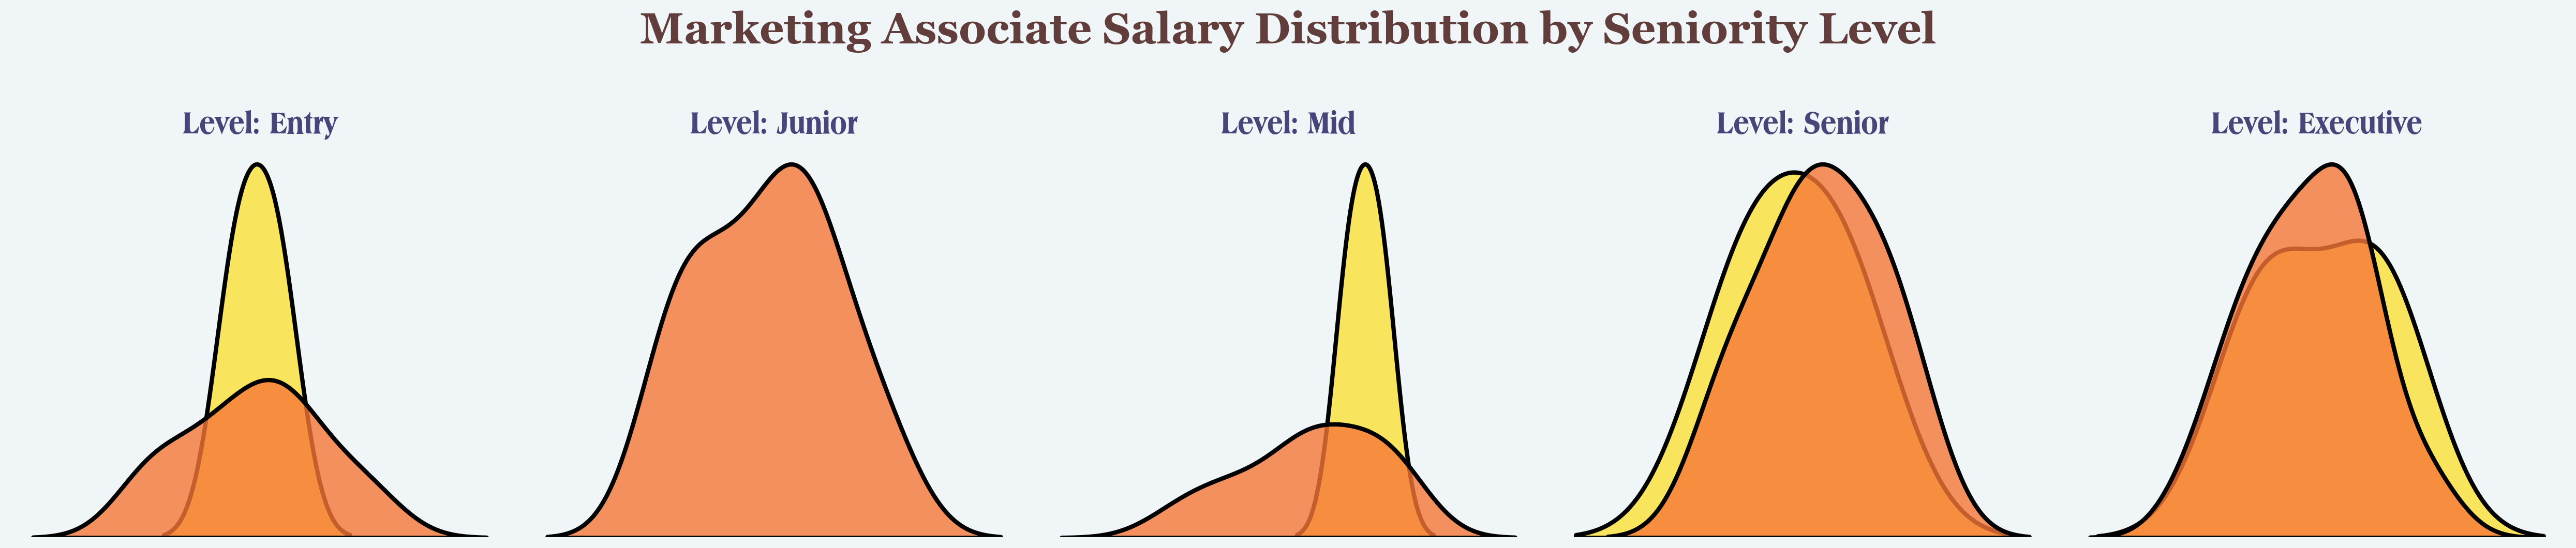

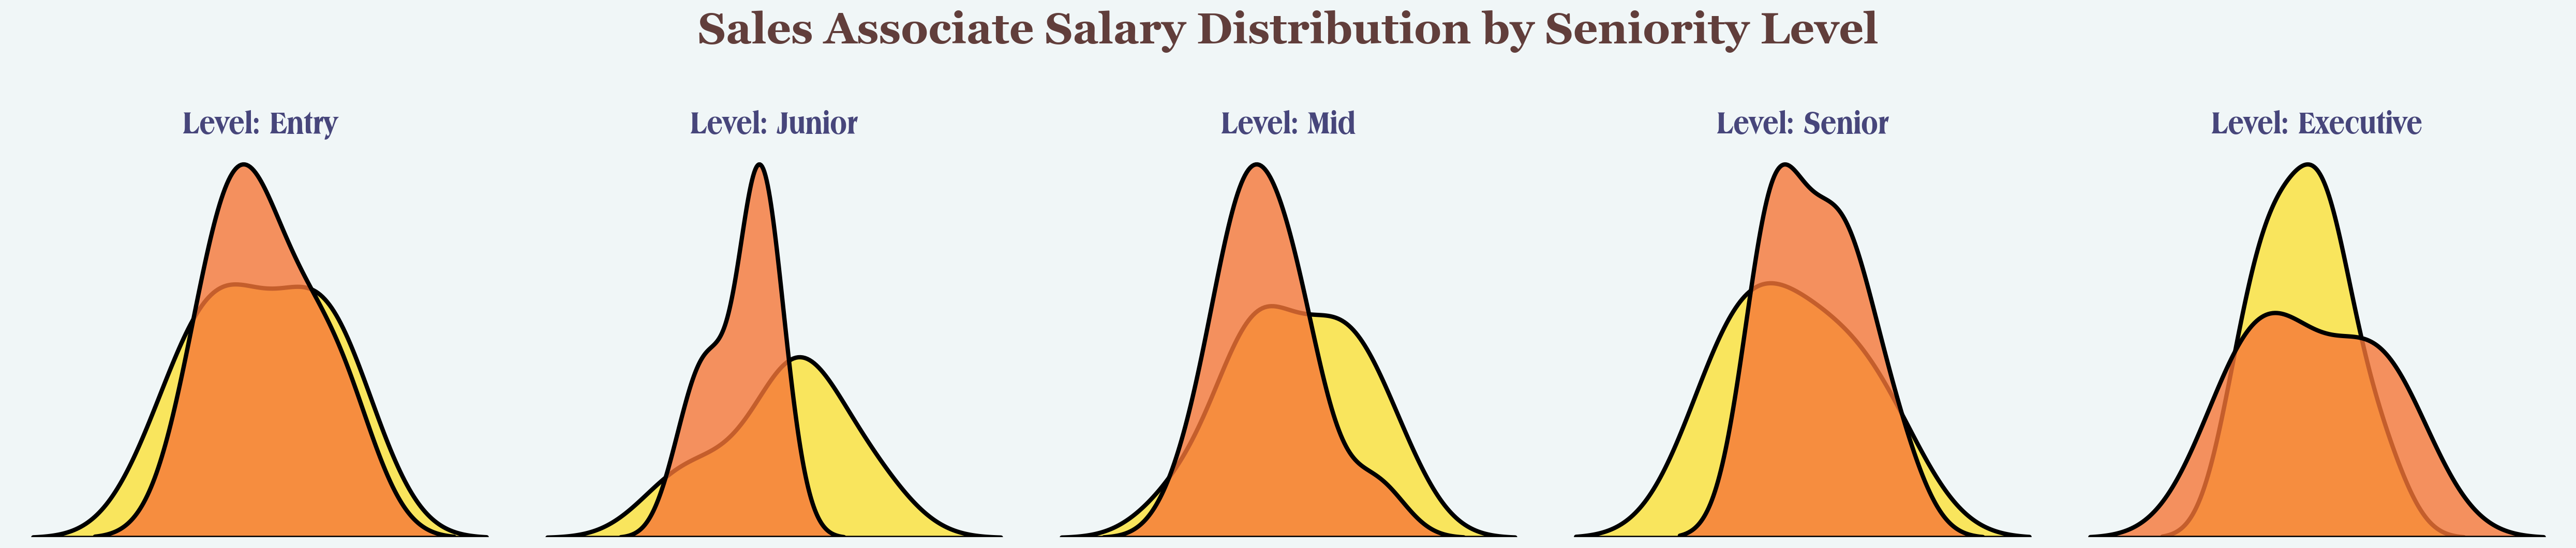

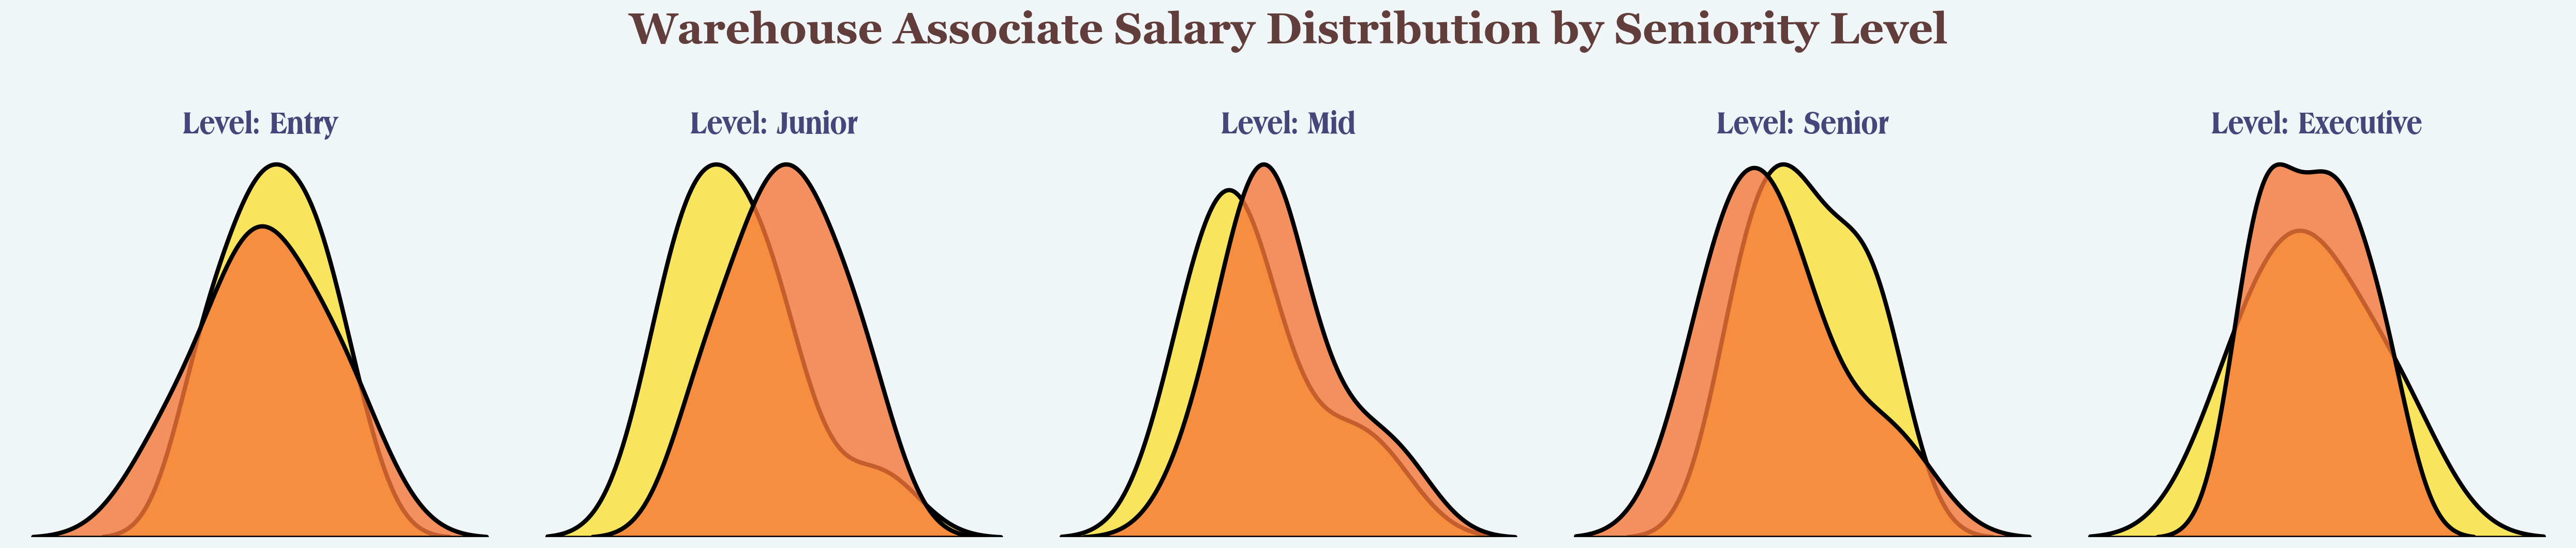

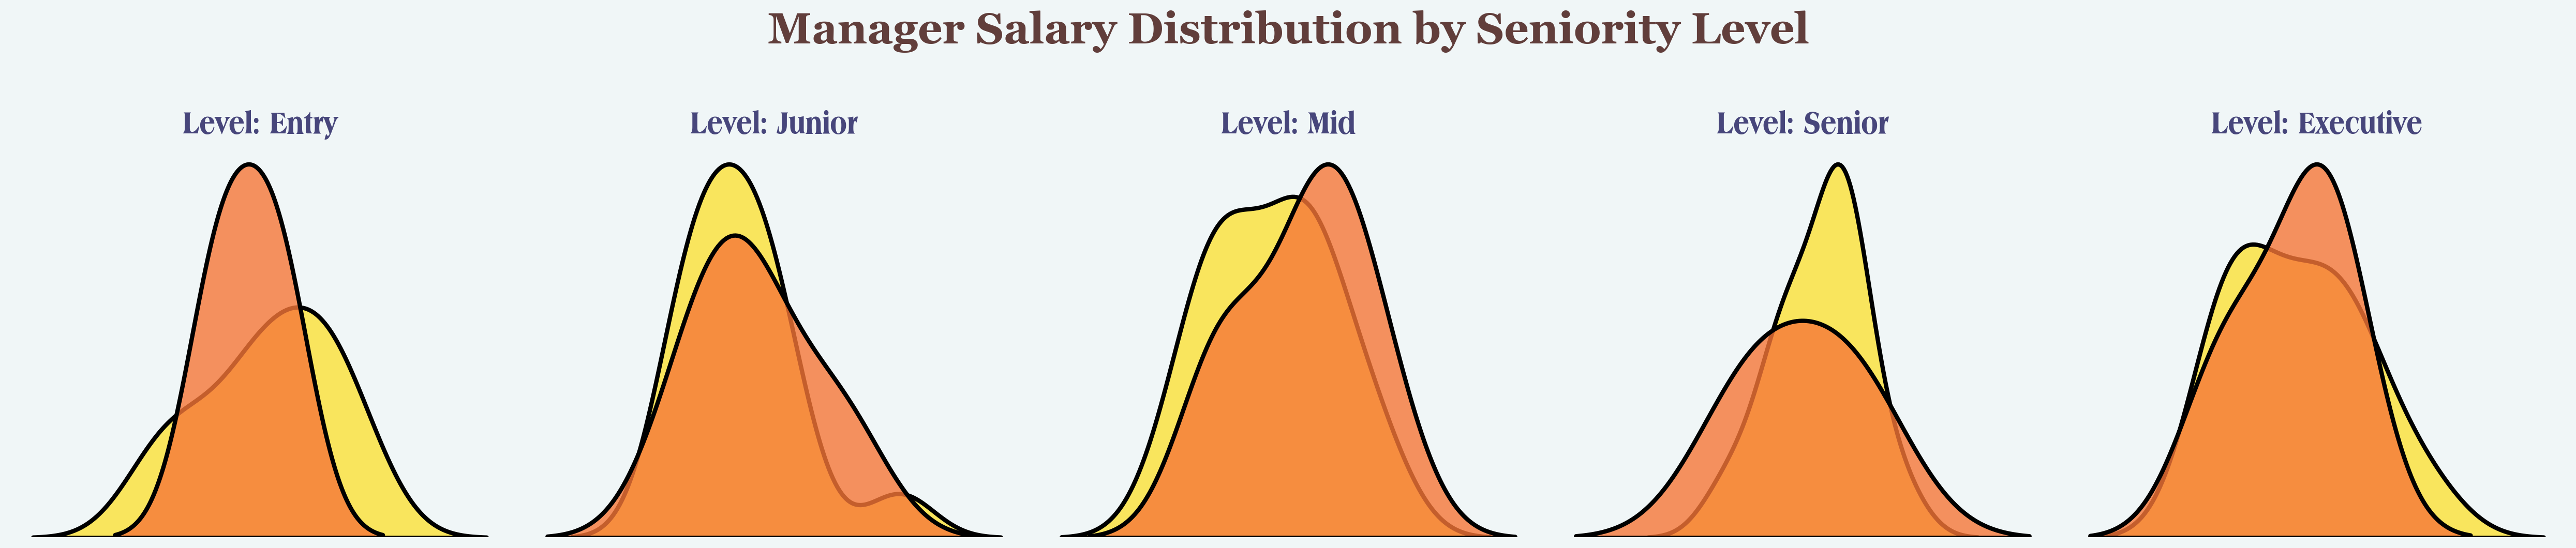

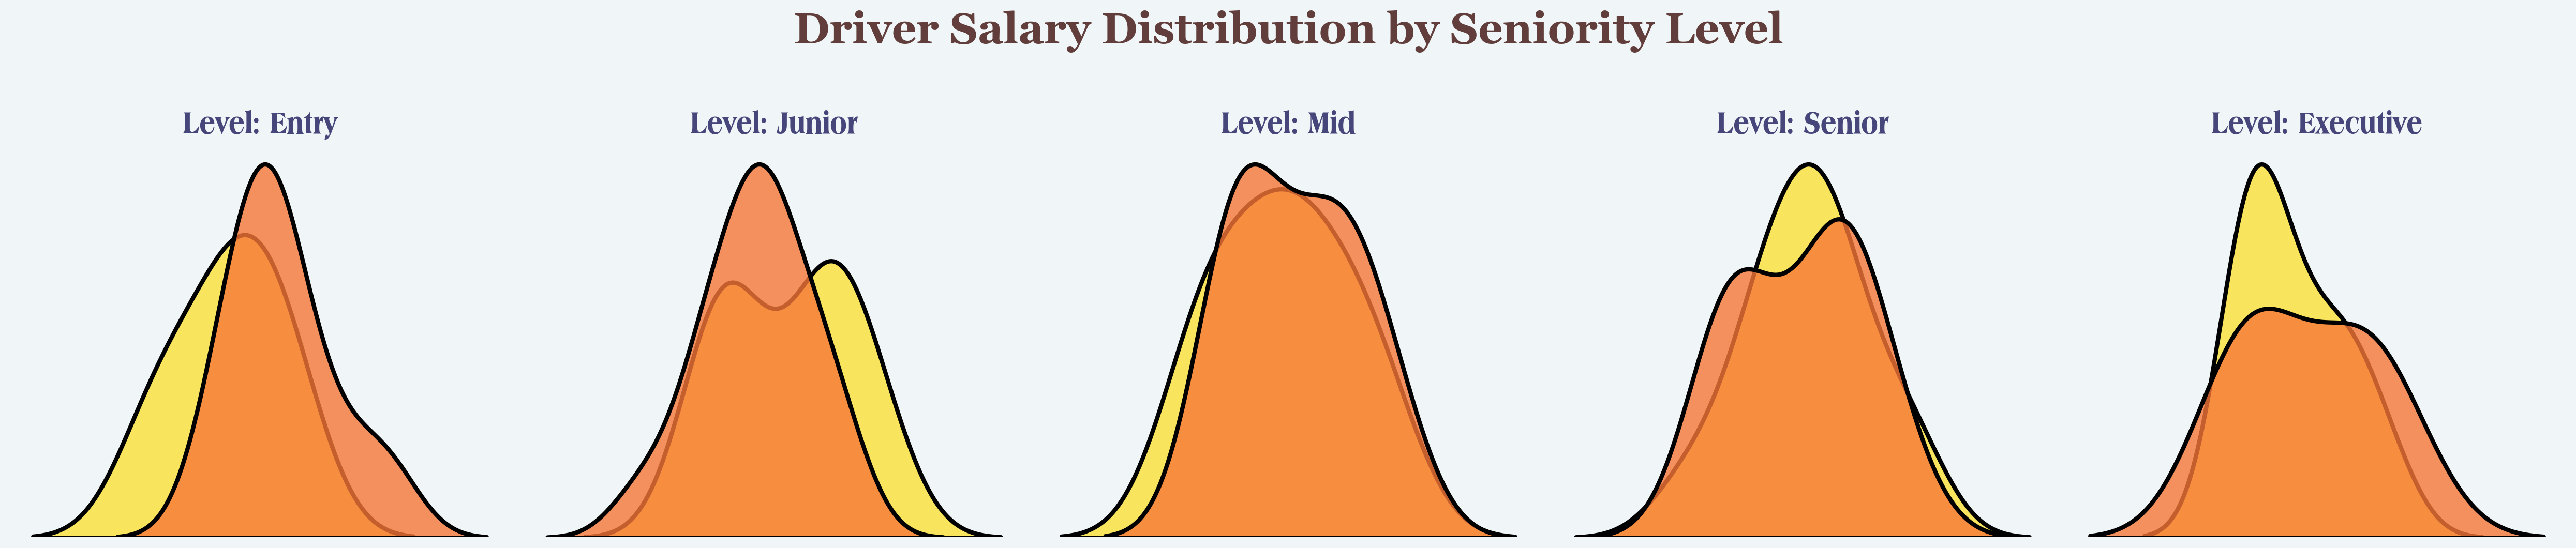

In [22]:
titles = ['Data Scientist','Financial Analyst','Software Engineer','Graphic Designer','IT',
          'Marketing Associate', 'Sales Associate','Warehouse Associate','Manager','Driver']
for title in titles:
    plot_kde_by_job(title)

<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 40px;
  font-weight: bold;
  background: linear-gradient(to right, #f6f5f2, #e8f0ef);
  letter-spacing: 3px;
  color: #47467b;
  border-radius: 10px;
  text-align: left;
  line-height: 1;
  padding: 5px 5px;
">
  <span>Department Analysis</span>
</h1>


In [23]:
# department
# - counts of genders according to titles wrt department
# - waffle of genders in departments
# - basepay boxplot distribution of genders wrt departments


In [24]:
def get_gender_distribution_df(df, dept_col='Department', gender_col='Gender'):
    ct = pd.crosstab(df[dept_col], df[gender_col])
    ct = ct.reindex(columns=['Male', 'Female'], fill_value=0)
    ct['Total'] = ct.sum(axis=1)
    ct['Male %'] = (ct['Male'] / ct['Total'] * 100).round(1)
    ct['Female %'] = (ct['Female'] / ct['Total'] * 100).round(1)
    ct['Workforce %'] = (ct['Total'] / ct['Total'].sum() * 100).round(1)
    return ct[['Male %', 'Female %', 'Workforce %']]

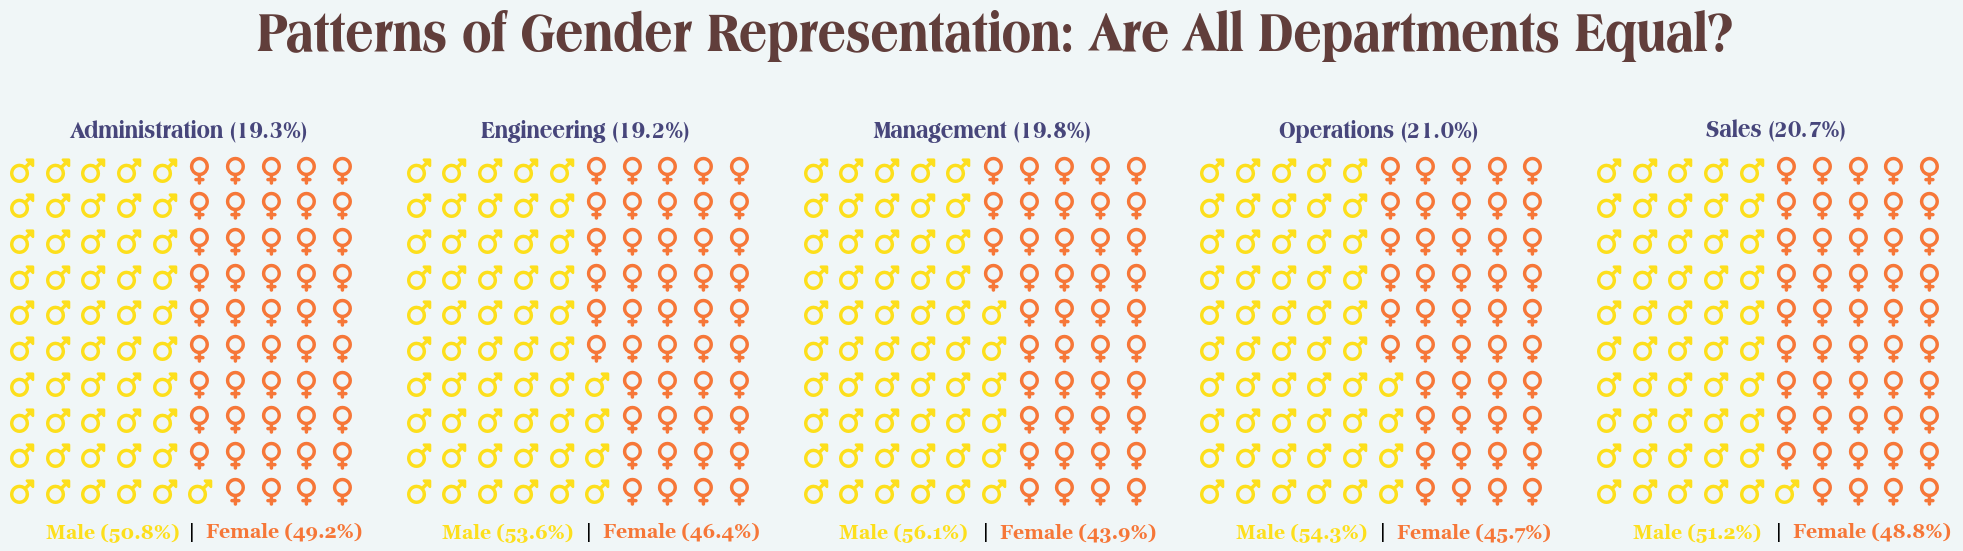

In [25]:
gender_df = get_gender_distribution_df(df, dept_col='Dept', gender_col='Gender')
plot1 = {
    'values': [gender_df.iloc[0]['Male %'], gender_df.iloc[0]['Female %']],'labels': ['Male', 'Female'],'icons':['mars', 'venus'],'colors': [colors1[0], colors2[0]],
    'icon_style': ['solid', 'solid'],'icon_size': 20,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

plot2 = {'values': [gender_df.iloc[1]['Male %'], gender_df.iloc[1]['Female %']],'labels': ['Male', 'Female'],'icons': ['mars', 'venus'],'colors': [colors1[0], colors2[0]],
    'icon_style': ['solid', 'solid'],'icon_size': 20,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

plot3 = {'values': [gender_df.iloc[2]['Male %'], gender_df.iloc[2]['Female %']],'labels': ['Male', 'Female'],'icons': ['mars', 'venus'],'colors': [colors1[0], colors2[0]],'icon_size': 20,
    'icon_style': ['solid', 'solid'],'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

plot4 = {'values': [gender_df.iloc[3]['Male %'], gender_df.iloc[3]['Female %']],'labels': ['Male', 'Female'],'icons': ['mars', 'venus'],'colors': [colors1[0], colors2[0]],
    'icon_style': ['solid', 'solid'],'icon_size': 20,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

plot5 = {'values': [gender_df.iloc[4]['Male %'], gender_df.iloc[4]['Female %']],'labels': ['Male', 'Female'],'icons':['mars', 'venus'],'colors': [colors1[0], colors2[0]],
    'icon_style': ['solid', 'solid'],'icon_size': 20,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

fig = plt.figure(FigureClass=Waffle,plots={151: plot1, 152: plot2, 153: plot3, 154: plot4, 155: plot5},rows=10,columns=10,figsize=(20, 7))
plt.subplots_adjust(wspace=0.8)
fig.set_facecolor(facecolor[0])
fig.suptitle("Patterns of Gender Representation: Are All Departments Equal?",fontsize=40,fontname=fonts[0],fontweight='bold',color=accent[0],y=0.9)

for i in range(5):
    fig.axes[i].text(0.5, 1.02,f"{gender_df.index[i]} ({gender_df.iloc[i]['Workforce %']}%)",ha='center',fontsize=18,
                     fontdict={'font': fonts[0],'weight': 'semibold','color': accent[1]})
    add_title1(ax=fig.axes[i],fontsize=14,x_vals=[0.1, 0.5, 0.55],y=-0.1,
               labels=[f"Male ({gender_df.iloc[i]['Male %']}%)","|",f"Female ({gender_df.iloc[i]['Female %']}%)"],colors=[colors1[0], "black", colors2[0]])
for ax in fig.axes:
    ax.legend().set_visible(False)
fig.show()


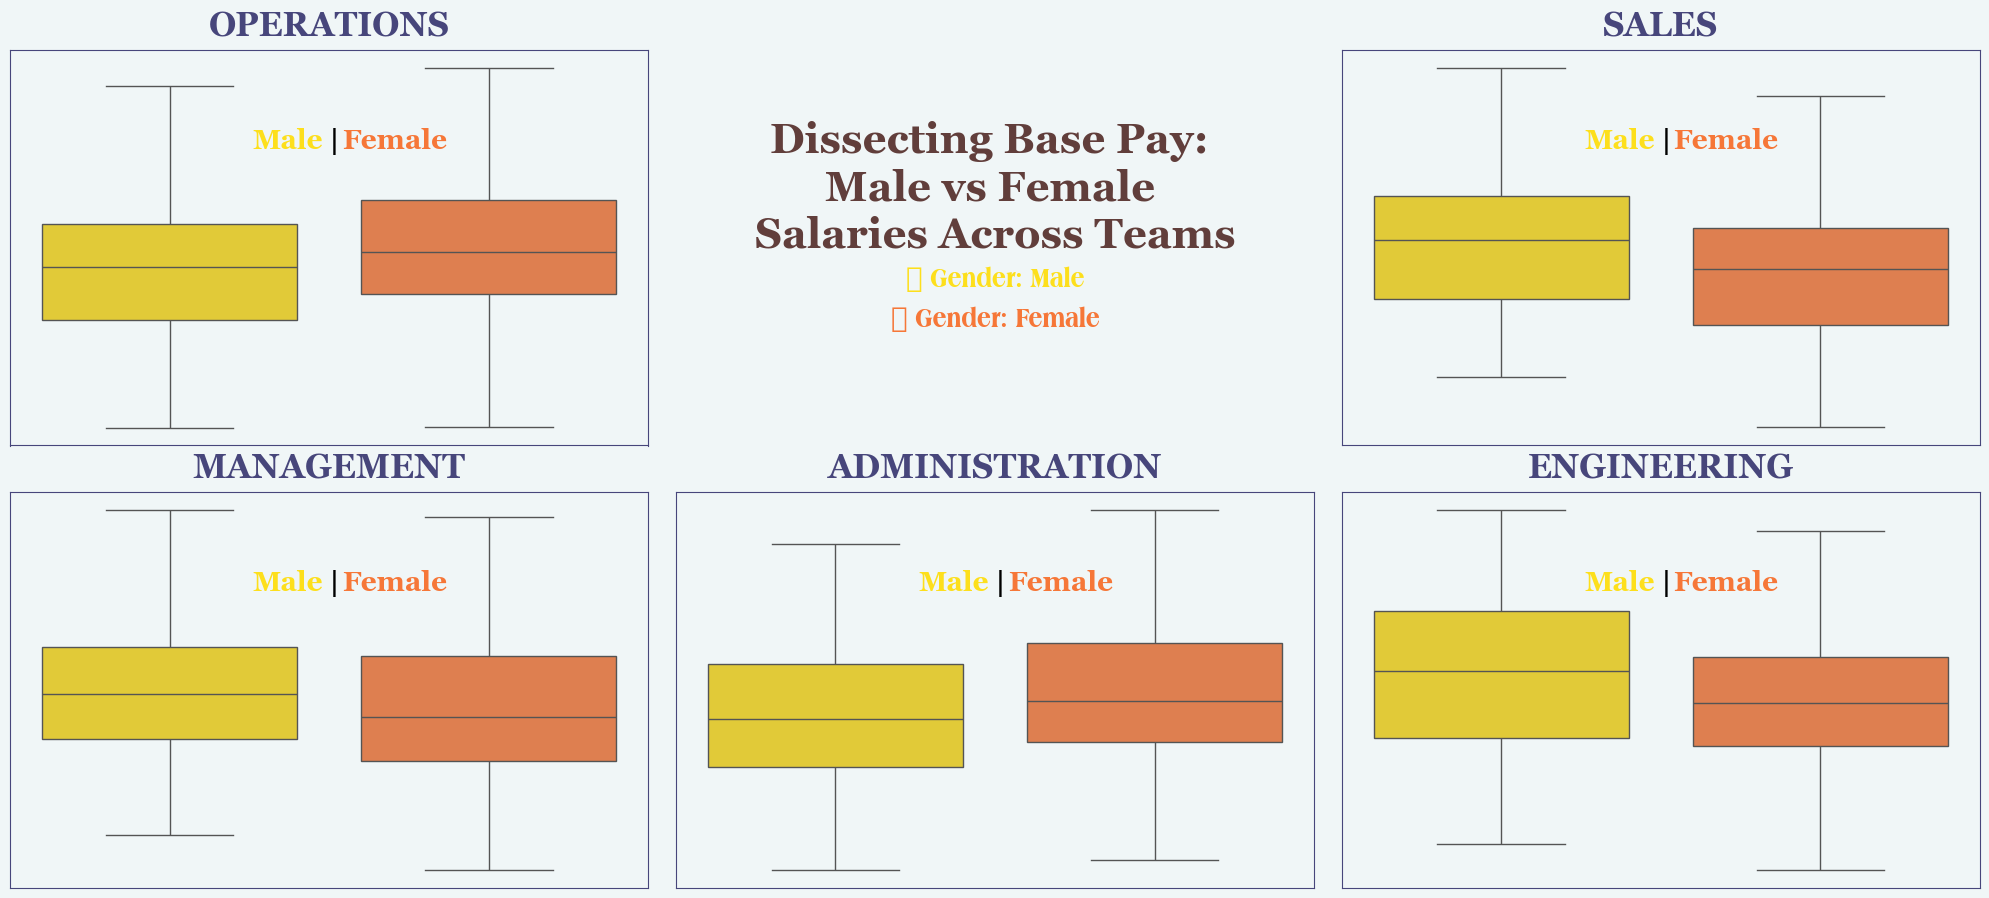

In [26]:
fig = plt.figure(figsize=(20, 9))
fig.patch.set_facecolor(facecolor[0])
departments = ['Operations', 'Sales', 'Management', 'Administration', 'Engineering']
positions = [(0, 0), (0, 2), (1, 0), (1, 1), (1, 2)]

for i, dept in enumerate(departments):
    ax = plt.subplot2grid((2, 3), positions[i])
    data = df[df["Dept"] == dept]
    ax.set_facecolor(facecolor[0])
    sns.boxplot(y=data["BasePay"],x=data["Gender"],palette=[colors1[0], colors2[0]],ax=ax,showfliers=False)
    ax.text(0.5, 1.1, dept.upper(), transform=ax.transAxes, ha="center", va="top",
            fontdict={'font': fonts[1], 'size': 24, 'color': accent[1], 'weight': 'bold'})
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_xticks([])
    add_title1(ax=ax, fontsize=20, x_vals=[0.38, 0.5, 0.52], y=0.75,labels=["Male", "|", "Female"],colors=[colors1[0], "black", colors2[0]])
    set_spines_color1(ax, accent[1])
ax_legend = plt.subplot2grid((2, 3), (0, 1))
ax_legend.set_facecolor(facecolor[0])
ax_legend.axis("off")
ax_legend.text(0.5, 0.5, "Dissecting Base Pay: \nMale vs Female \nSalaries Across Teams", fontsize=30, ha="center",
               color=accent[0], fontweight="bold", font=fonts[1])
ax_legend.text(0.5, 0.4, "● Gender: Male", fontsize=20, color=colors1[0],
               fontweight="normal", font=fonts[0], ha="center")
ax_legend.text(0.5, 0.3, "● Gender: Female", fontsize=20, color=colors2[0],
               fontweight="normal", font=fonts[0], ha="center")

plt.tight_layout()
plt.show()


In [27]:
gender_counts = df.groupby(['Dept', 'JobTitle', 'Gender']).size().unstack(fill_value=0).reset_index()
gender_counts.columns.name = None
gender_counts = gender_counts.rename(columns={'Female': 'GenderFemale', 'Male': 'GenderMale'})
gender_counts['Total'] = gender_counts['GenderFemale'] + gender_counts['GenderMale']

dept_order = gender_counts.groupby('Dept')['Total'].sum().sort_values(ascending=False).index
gender_counts['Dept'] = pd.Categorical(gender_counts['Dept'], categories=dept_order, ordered=True)
gender_counts = gender_counts.sort_values(['Dept', 'Total'], ascending=[True, False])
gender_counts.head()

,Dept,JobTitle,GenderFemale,GenderMale,Total
32,Operations,Financial Analyst,12,19,31
30,Operations,Data Scientist,11,13,24
33,Operations,Graphic Designer,13,10,23
36,Operations,Marketing Associate,19,2,21
37,Operations,Sales Associate,10,10,20


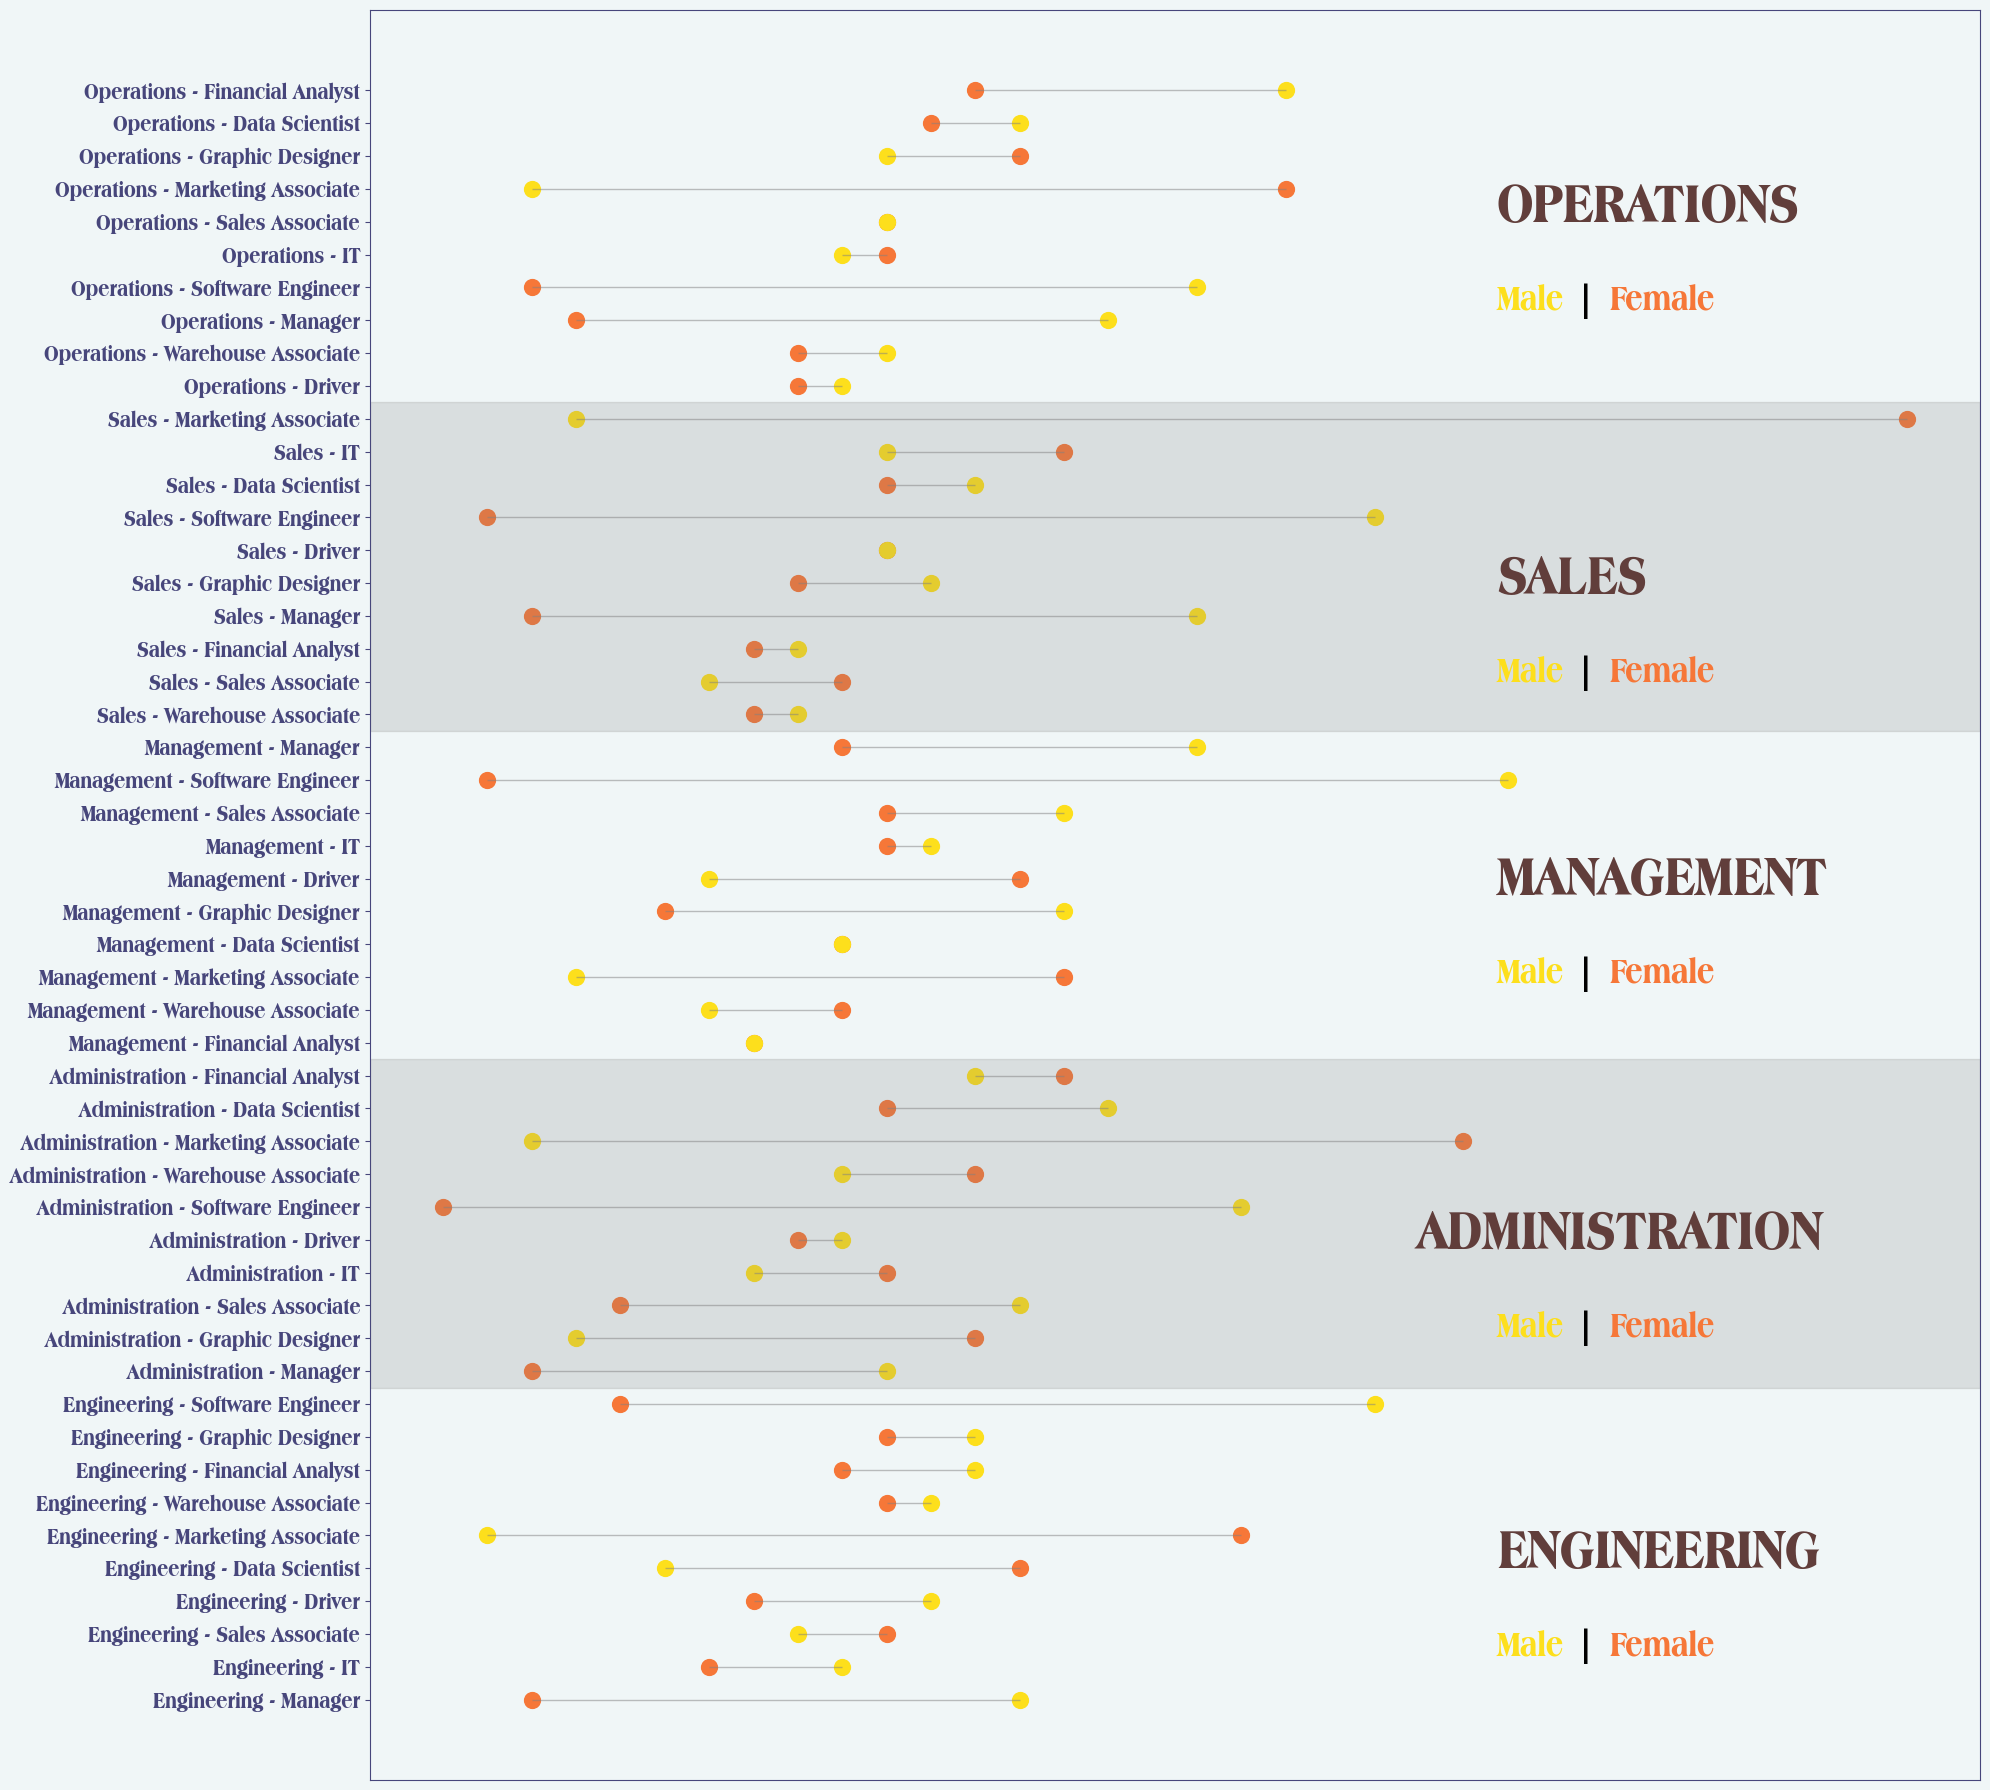

In [28]:
gender_counts["Role"] = gender_counts["Dept"].astype(str) + " - " + gender_counts["JobTitle"].astype(str)
fig, ax = plt.subplots(figsize=(20, 18), facecolor=facecolor[0],dpi=100)
fig.patch.set_facecolor(facecolor[0])
ax.set_facecolor(facecolor[0])  

ax.hlines(y=gender_counts['Role'],xmin=gender_counts['GenderFemale'],xmax=gender_counts['GenderMale'],color='grey', alpha=0.5, linewidth=1)

# Female (blue)
ax.scatter(gender_counts['GenderFemale'],gender_counts['Role'],color=colors2[0], s=130)

# Male (green)
ax.scatter(gender_counts['GenderMale'],gender_counts['Role'],color=colors1[0], s=130)

# Y-axis display as-is
ax.set_xlabel("")
ax.set_xticks([])
ax.set_ylabel("")
ax.tick_params(axis='y', labelsize=10, colors=accent[1])
ax.set_yticklabels(gender_counts['Role'], fontdict={'fontsize': 16, 'color': accent[1], 'fontname': fonts[0], 'weight': 'semibold'})
ax.invert_yaxis()

ax.set_title("",fontsize=14, color=accent[0], pad=20)
set_spines_color1(ax, accent[1])
ops_range = gender_counts[gender_counts["Dept"] == "Operations"].index
eng_range = gender_counts[gender_counts["Dept"] == "Engineering"].index
ax.axhspan(ops_range.min() - 0.5, ops_range.max() + 0.5, color='grey', alpha=0.2)
ax.axhspan(eng_range.min() - 0.5, eng_range.max() + 0.5, color='grey', alpha=0.2)
add_title2(ax=ax, fontsize=40, x_vals=[0.7,0.7,0.7,0.65,0.7], y_vals=[0.88,0.67,0.5,0.3,0.12],
                  labels=["OPERATIONS", "SALES", "MANAGEMENT", "ADMINISTRATION", "ENGINEERING"],
                  colors=[accent[0],accent[0],accent[0],accent[0],accent[0]])
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.83, 0.83, 0.83],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.62, 0.62, 0.62],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.45, 0.45, 0.45],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.25, 0.25, 0.25],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.07, 0.07, 0.07],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
plt.tight_layout()
plt.show()


<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 40px;
  font-weight: bold;
  background: linear-gradient(to right, #f6f5f2, #e8f0ef);
  letter-spacing: 3px;
  color: #47467b;
  border-radius: 10px;
  text-align: left;
  line-height: 1;
  padding: 5px 5px;
">
  <span>Seniority Analysis</span>
</h1>


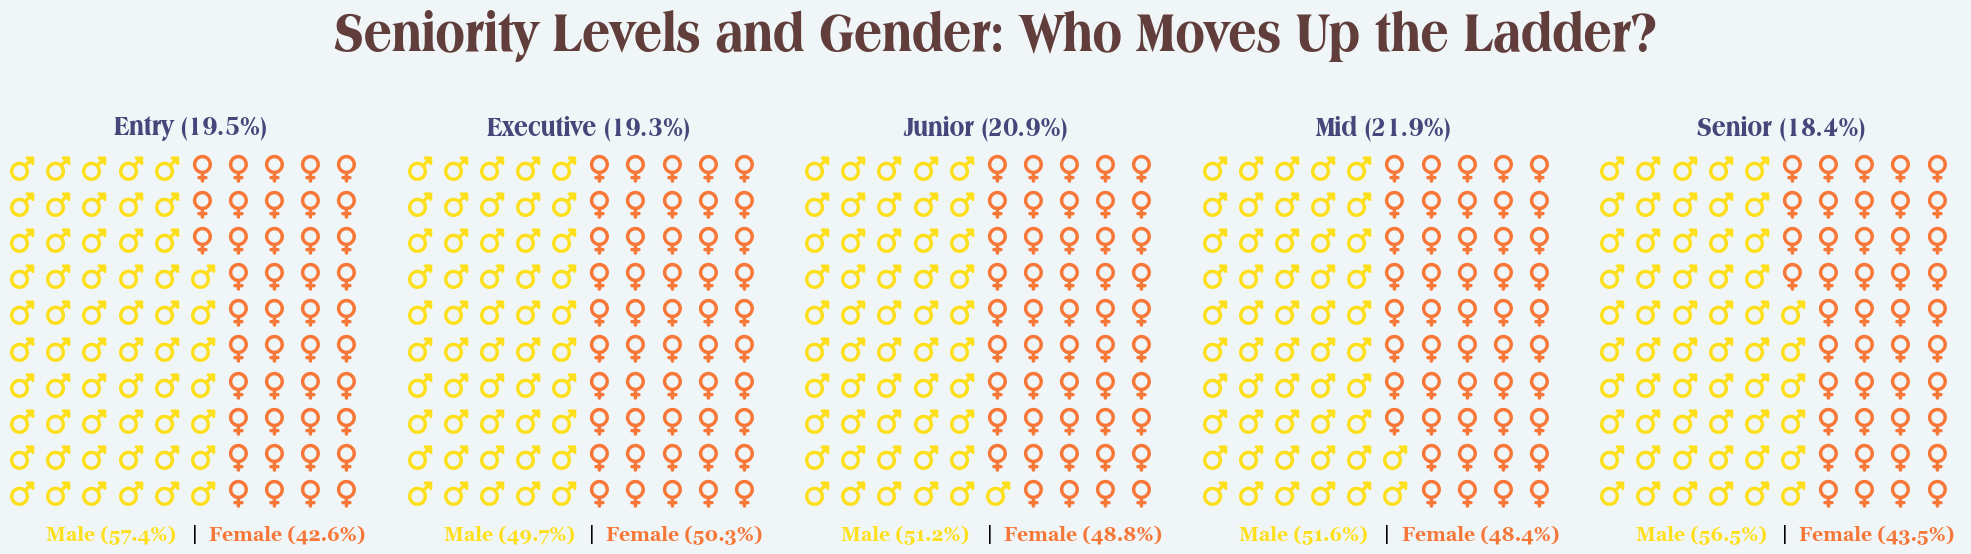

In [29]:
gender_df = get_gender_distribution_df(df, dept_col='SeniorityLevel', gender_col='Gender')
plot1 = {
    'values': [gender_df.iloc[0]['Male %'], gender_df.iloc[0]['Female %']],'labels': ['Male', 'Female'],'icons':['mars', 'venus'],'colors': [colors1[0], colors2[0]],
    'icon_size': 20,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

plot2 = {'values': [gender_df.iloc[1]['Male %'], gender_df.iloc[1]['Female %']],'labels': ['Male', 'Female'],'icons': ['mars', 'venus'],'colors': [colors1[0], colors2[0]],
    'icon_size': 20,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

plot3 = {'values': [gender_df.iloc[2]['Male %'], gender_df.iloc[2]['Female %']],'labels': ['Male', 'Female'],'icons': ['mars', 'venus'],'colors': [colors1[0], colors2[0]],'icon_size': 20,
    'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

plot4 = {'values': [gender_df.iloc[3]['Male %'], gender_df.iloc[3]['Female %']],'labels': ['Male', 'Female'],'icons': ['mars', 'venus'],'colors': [colors1[0], colors2[0]],
    'icon_size': 20,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

plot5 = {'values': [gender_df.iloc[4]['Male %'], gender_df.iloc[4]['Female %']],'labels': ['Male', 'Female'],'icons':['mars', 'venus'],'colors': [colors1[0], colors2[0]],
    'icon_size': 20,'icon_legend': False,'interval_ratio_x': 0.001,'interval_ratio_y': 0.001,'plot_anchor': 'C','alpha': 0.9}

fig = plt.figure(FigureClass=Waffle,plots={151: plot1, 152: plot2, 153: plot3, 154: plot4, 155: plot5},rows=10,columns=10,figsize=(20,7))
plt.subplots_adjust(wspace=0.8)
fig.set_facecolor(facecolor[0])
fig.suptitle("Seniority Levels and Gender: Who Moves Up the Ladder?",fontsize=40,fontname=fonts[0],fontweight='bold',color=accent[0],y=0.9)
# Add department names below each subplot
for i in range(5):
    fig.axes[i].text(0.5, 1.02,f"{gender_df.index[i]} ({gender_df.iloc[i]['Workforce %']}%)",ha='center',fontsize=20,
                     fontdict={'font': fonts[0],'weight': 'semibold','color': accent[1]})
    # Bottom title: Male % | Female %
    add_title1(ax=fig.axes[i],fontsize=14,x_vals=[0.1, 0.5, 0.55],y=-0.1,
               labels=[f"Male ({gender_df.iloc[i]['Male %']}%)","|",f"Female ({gender_df.iloc[i]['Female %']}%)"],colors=[colors1[0], "black", colors2[0]])
for ax in fig.axes:
    ax.legend().set_visible(False)
fig.show()


In [30]:
gender_count = df.groupby(['SeniorityLevel', 'JobTitle', 'Gender']).size().unstack(fill_value=0).reset_index()
gender_count.columns.name = None
gender_count = gender_count.rename(columns={'Female': 'GenderFemale', 'Male': 'GenderMale'})
gender_count["Total"] = gender_count["GenderFemale"] + gender_count["GenderMale"]
seniority_order = pd.CategoricalDtype(categories=["Executive","Senior","Mid", "Junior","Entry"], ordered=True)
gender_count["SeniorityLevel"] = gender_count["SeniorityLevel"].astype(seniority_order)
gender_count = gender_count.sort_values(by=["SeniorityLevel", "Total"], ascending=[True, False]).reset_index(drop=True)
gender_count = gender_count[["SeniorityLevel", "JobTitle", "GenderFemale", "GenderMale", "Total"]]
gender_count.head()
gender_count["Role"] = gender_count["SeniorityLevel"].astype(str) + " - " + gender_count["JobTitle"].astype(str)

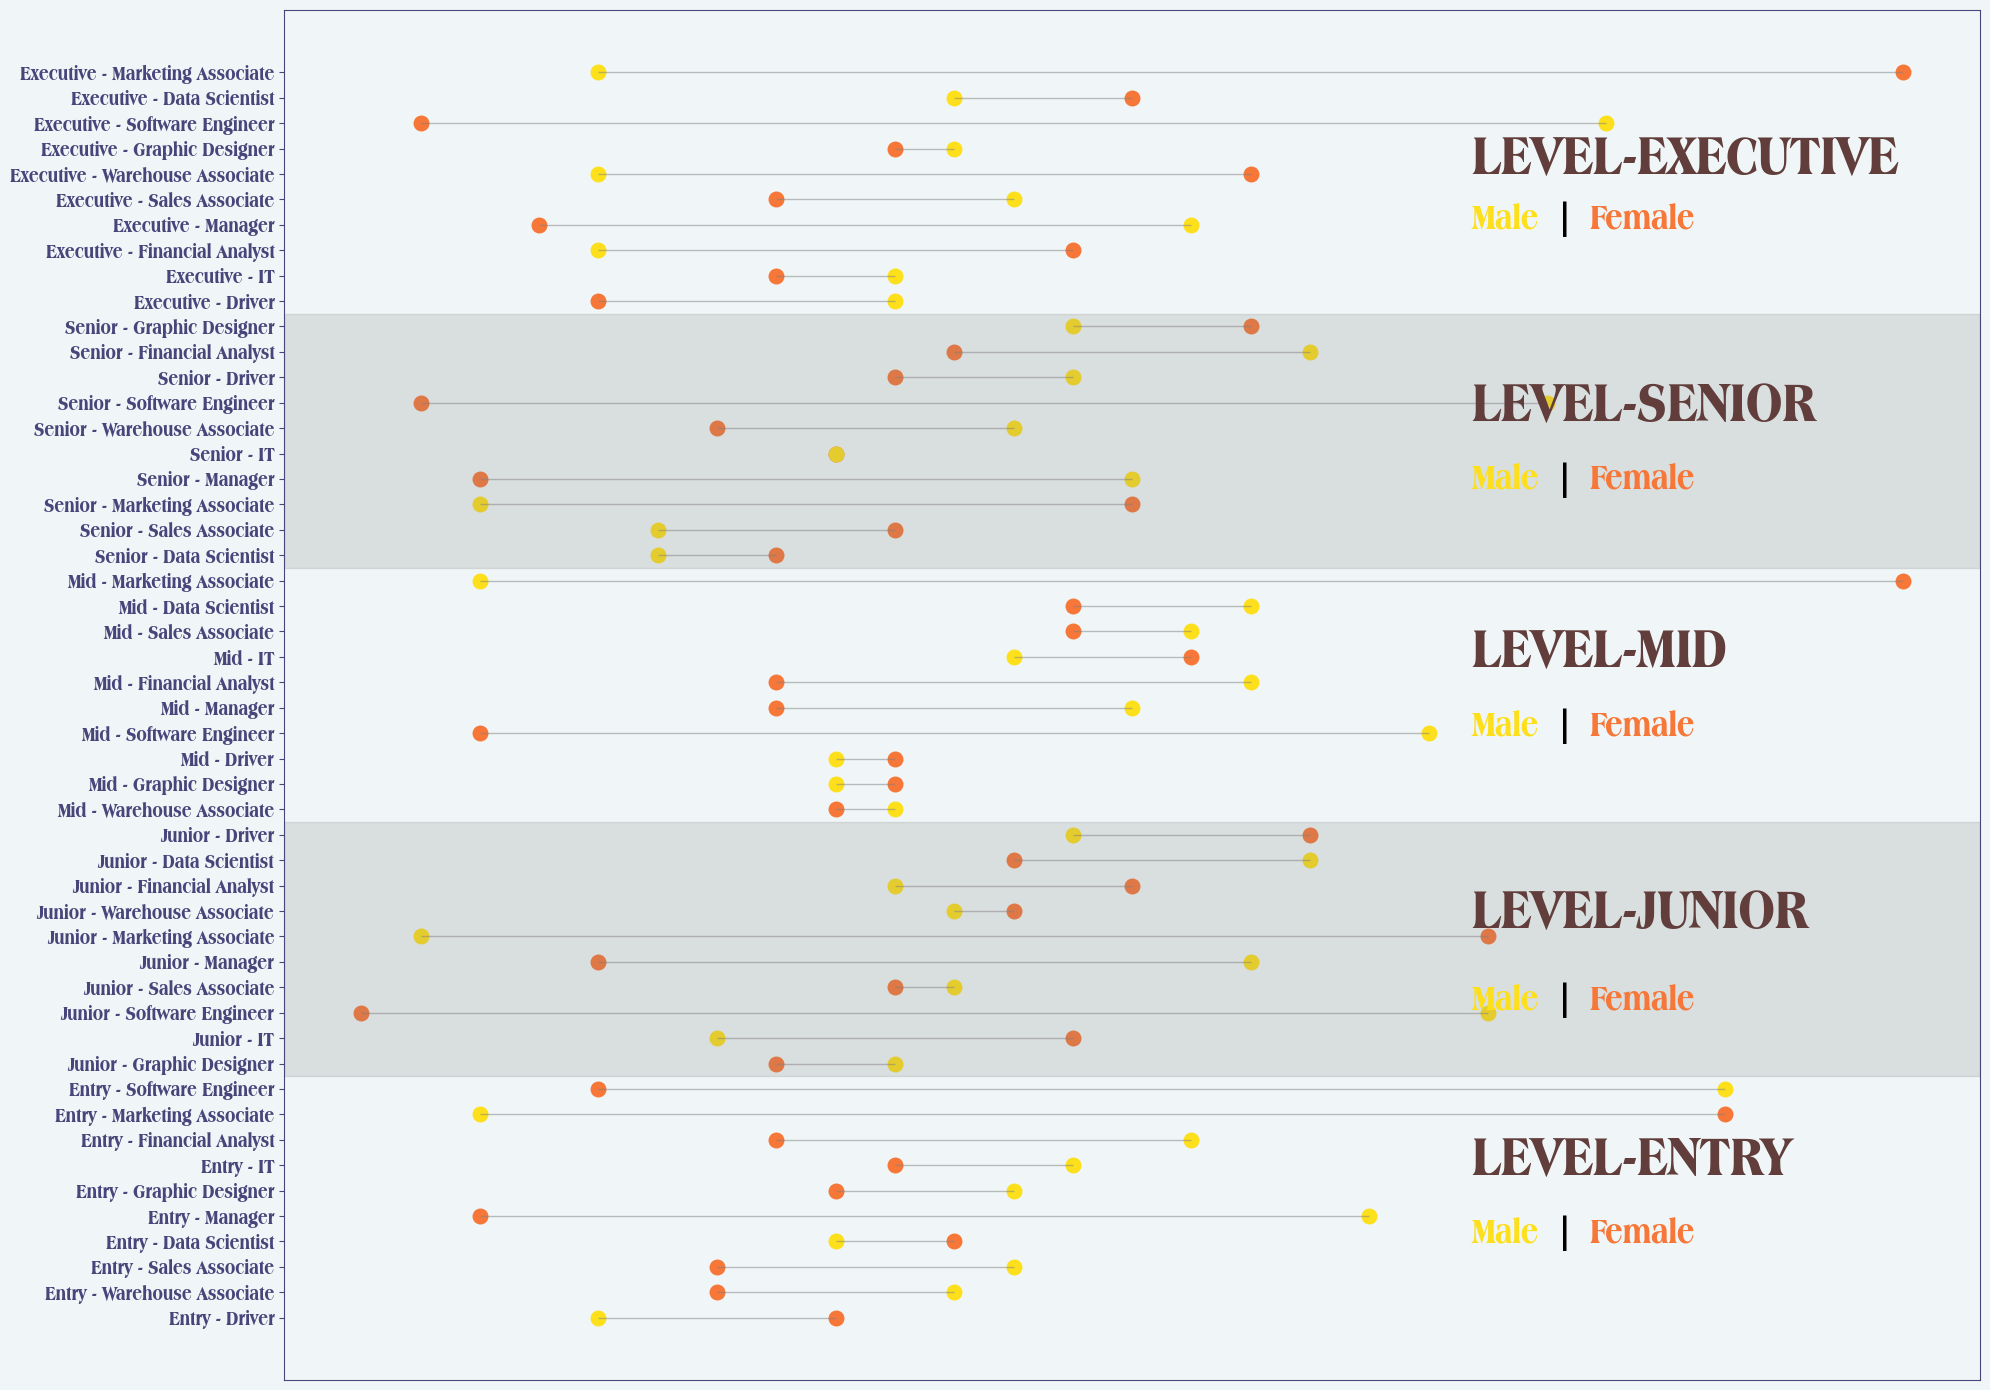

In [31]:
fig, ax = plt.subplots(figsize=(20, 14), facecolor=facecolor[0], dpi=100)
fig.patch.set_facecolor(facecolor[0])
ax.set_facecolor(facecolor[0])
ax.hlines(y=gender_count['Role'],xmin=gender_count['GenderFemale'],xmax=gender_count['GenderMale'],color='grey', alpha=0.5, linewidth=1)
# Female dots
ax.scatter(gender_count['GenderFemale'],gender_count['Role'],color=colors2[0], s=110)
# Male dots
ax.scatter(gender_count['GenderMale'],gender_count['Role'],color=colors1[0], s=110)
ax.set_xlabel("")
ax.set_xticks([])
ax.set_ylabel("")
ax.tick_params(axis='y', labelsize=10, colors=accent[1])
ax.set_yticklabels(gender_count['Role'],
                   fontdict={'fontsize': 14, 'color': accent[1], 'fontname': fonts[0], 'weight': 'semibold'})
ax.invert_yaxis()
add_title2(ax=ax, fontsize=40,x_vals=[0.7, 0.7, 0.7, 0.7, 0.7],y_vals=[0.88, 0.70, 0.52, 0.33, 0.15],labels=["LEVEL-EXECUTIVE", "LEVEL-SENIOR", "LEVEL-MID", "LEVEL-JUNIOR", "LEVEL-ENTRY"],colors=[accent[0]] * 5)
for level in ["Senior", "Junior"]:
    level_range = gender_count[gender_count["SeniorityLevel"] == level].index
    if not level_range.empty:
        ax.axhspan(level_range.min() - 0.5, level_range.max() + 0.5, color='grey', alpha=0.2)
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.84, 0.84, 0.84],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.65, 0.65, 0.65],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.47, 0.47, 0.47],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.27, 0.27, 0.27],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
add_title2(ax=ax, fontsize=25, x_vals=[0.7, 0.75, 0.77], y_vals=[0.1, 0.1, 0.1],labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])

ax.set_title("", fontsize=14, color=accent[0], pad=20)
set_spines_color1(ax, accent[1])

plt.tight_layout()
plt.show()


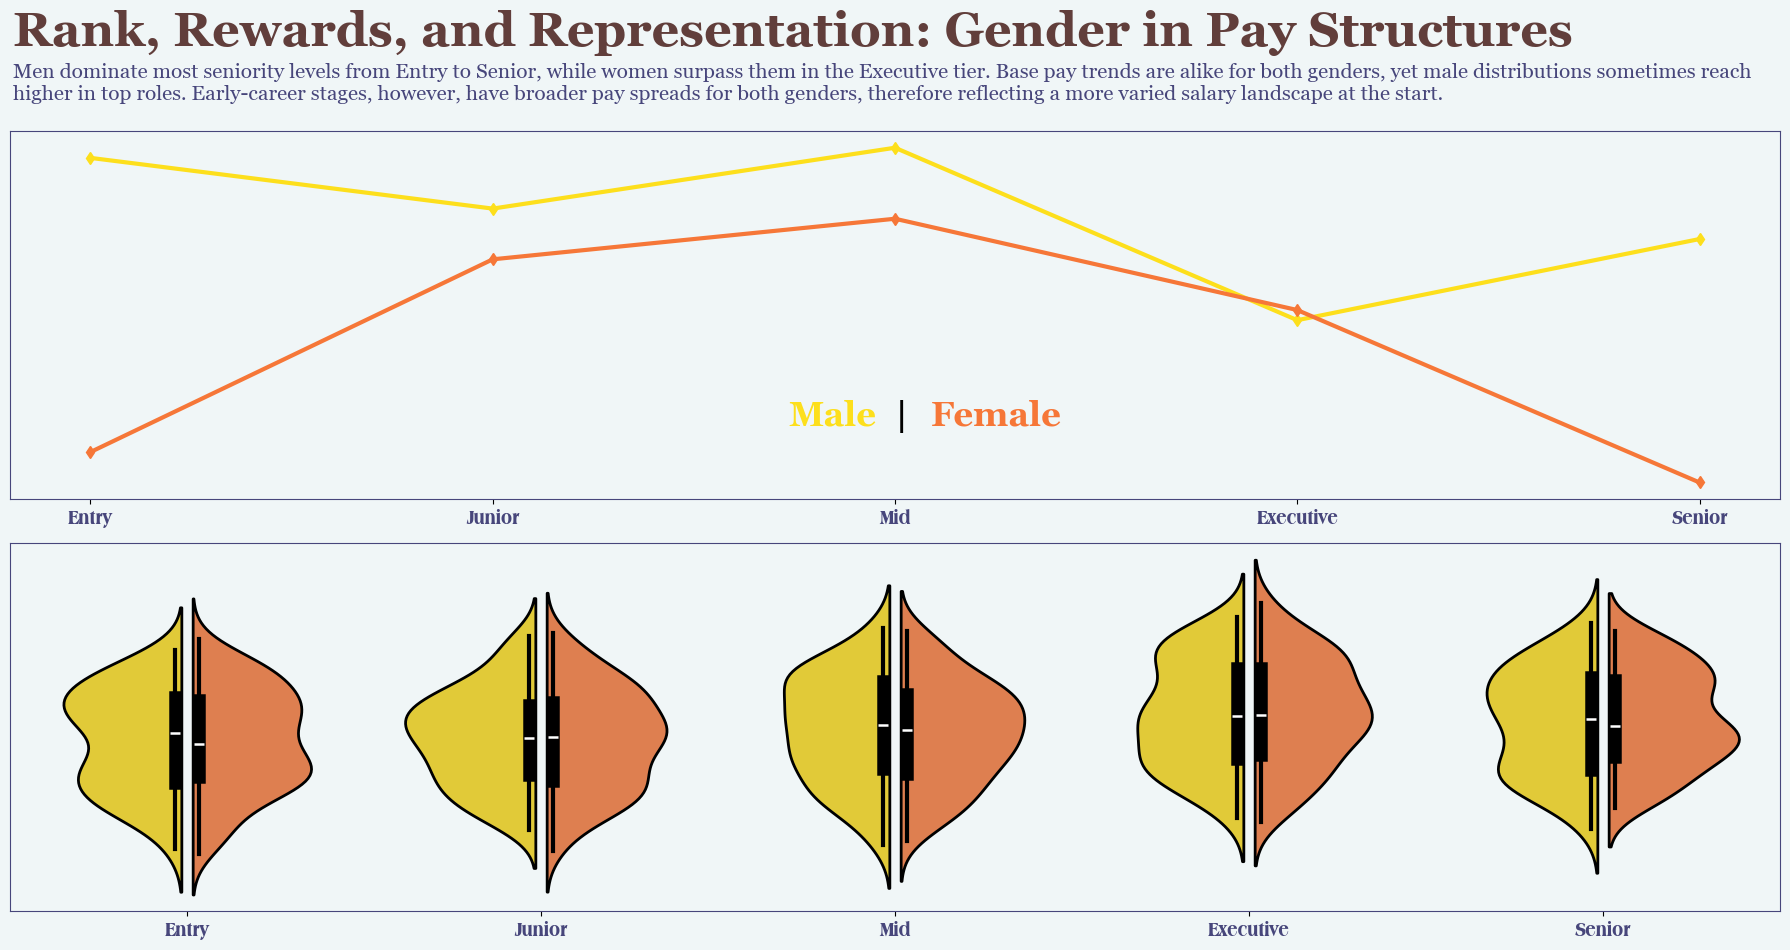

In [32]:
seniority_order = ["Entry", "Junior", "Mid", "Executive", "Senior"]
palette= [colors1[0],colors2[0]]
fig = plt.figure(figsize=(18, 9), facecolor=facecolor[0], dpi=100)
fig.suptitle("Rank, Rewards, and Representation: Gender in Pay Structures",fontsize=35, color=accent[0], fontweight='bold', font=fonts[1],x=0.01,y=1.05,ha='left')
fig.text(0.01,0.95,"Men dominate most seniority levels from Entry to Senior, while women surpass them in the Executive tier. Base pay trends are alike for both genders, yet male distributions sometimes reach \nhigher in top roles. Early-career stages, however, have broader pay spreads for both genders, therefore reflecting a more varied salary landscape at the start.",
         font= fonts[1],color=accent[1],fontweight="normal",fontsize=15)
ax0 = plt.subplot2grid((2, 1), (0, 0))
ax0.set_facecolor(facecolor[0])
count_data = df.groupby(['SeniorityLevel', 'Gender']).size().reset_index(name='Count')
count_data['SeniorityLevel'] = pd.Categorical(count_data['SeniorityLevel'], categories=seniority_order, ordered=True)

for gender in ['Male', 'Female']:
    subset = count_data[count_data['Gender'] == gender].sort_values('SeniorityLevel')
    ax0.plot(subset['SeniorityLevel'], subset['Count'], marker='d', color=color_map[gender], label=gender, linewidth=3)
ax0.set_xticklabels(ax0.get_xticklabels(),fontdict={'fontfamily': fonts[0], 'weight': 'bold','color':accent[1],'fontsize':15})
add_title1(ax=ax0, fontsize=25, x_vals=[0.44, 0.5, 0.52], y=0.2,labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
ax0.set_yticks([])
ax0.set_xlabel("")
ax0.set_ylabel("")
set_spines_color1(ax0, accent[1])

# Second plot (row 1) - Bonus distribution by SeniorityLevel & Gender
ax1 = plt.subplot2grid((2, 1), (1, 0))
ax1.set_facecolor(facecolor[0])
sns.violinplot(x=df["SeniorityLevel"], y=df["Bonus"], hue=df["Gender"], split=True,gap=0.08, linewidth=2,edgecolor="black",
               ax=ax1, palette=palette, order=seniority_order)  # <-- order enforced

ax1.legend().remove()
ax1.set_yticks([])
ax1.set_xticklabels(ax1.get_xticklabels(),fontdict={'fontfamily': fonts[0], 'weight': 'bold','color':accent[1],'fontsize':15})
ax1.set_xlabel("")
ax1.set_ylabel("")
set_spines_color1(ax1, accent[1])

plt.tight_layout()
plt.show()


<h1 style="
  font-family: 'Americana XBdCn BT';
  text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
  font-size: 40px;
  font-weight: bold;
  background: linear-gradient(to right, #f6f5f2, #e8f0ef);
  letter-spacing: 3px;
  color: #47467b;
  border-radius: 10px;
  text-align: left;
  line-height: 1;
  padding: 5px 5px;
">
  <span>Further Related Analysis</span>
</h1>


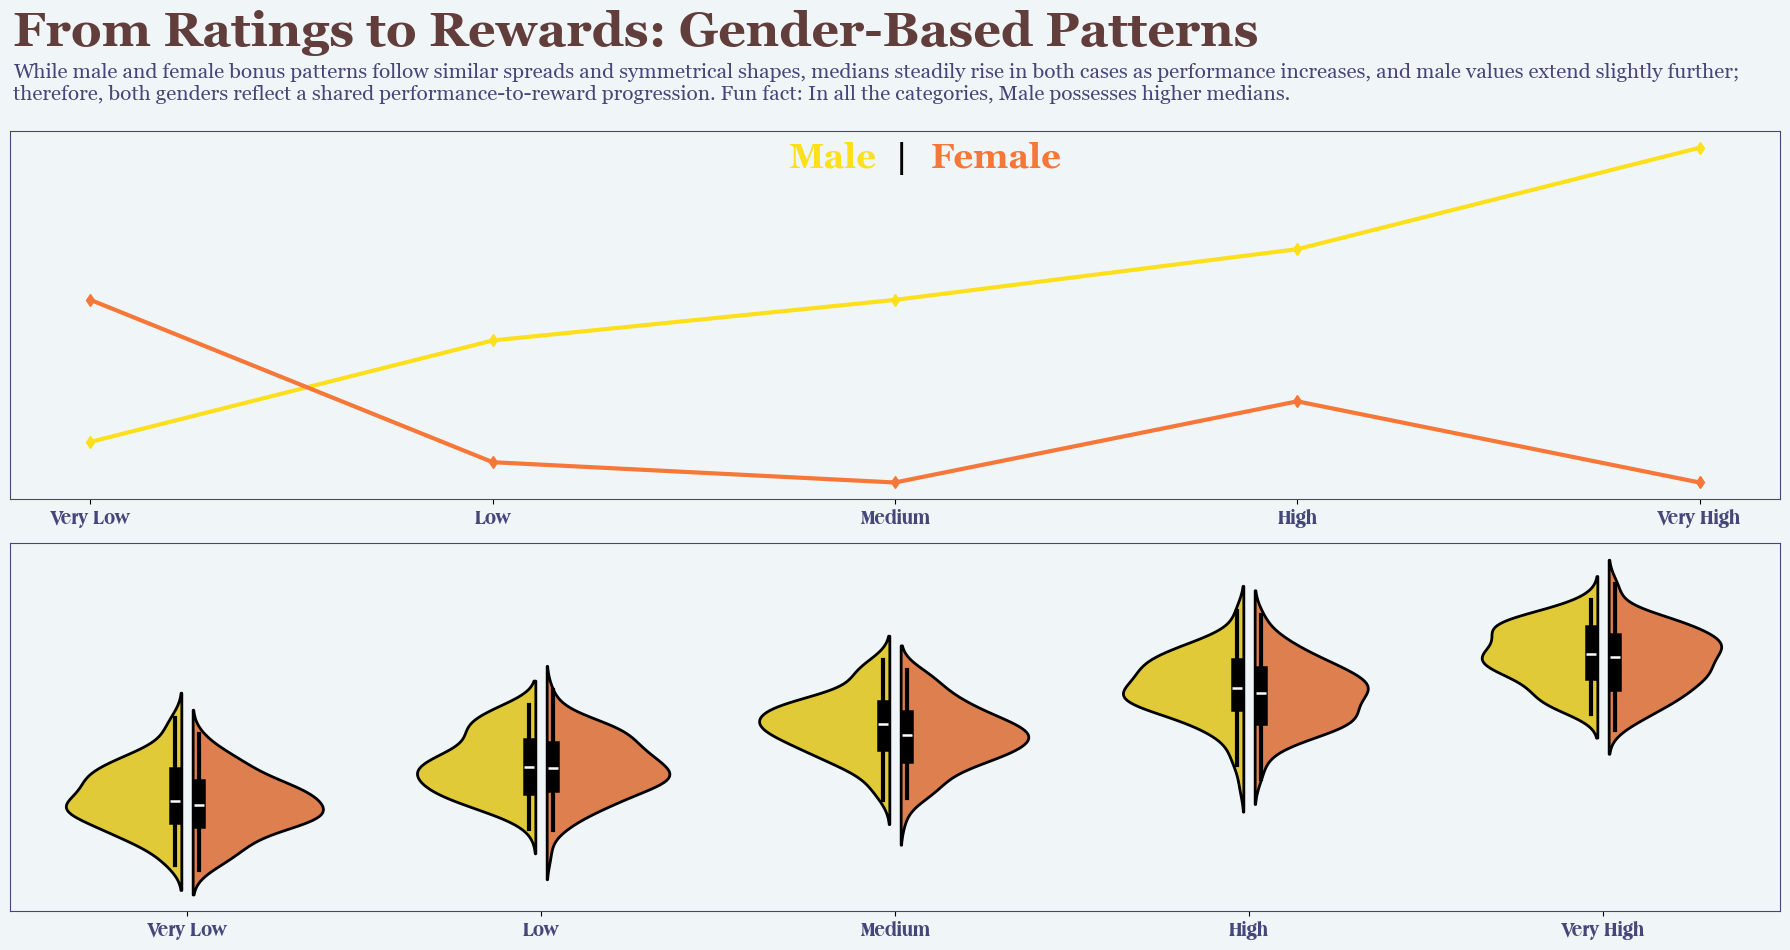

In [33]:
fig = plt.figure(figsize=(18, 9), facecolor=facecolor[0],dpi=100)
fig.suptitle("From Ratings to Rewards: Gender-Based Patterns",fontsize=35, color=accent[0], fontweight='bold', font=fonts[1],x=0.01,y=1.05,ha='left')
# fig.text(0,1,"The strong correlation (0.86) between Bonus and Performance Evaluation is evident, with males showing slightly higher median bonuses across most evaluation levels.",
#          font= fonts[0],color=accent[1],fontweight="normal",fontsize=15)
fig.text(0.01,0.95,"While male and female bonus patterns follow similar spreads and symmetrical shapes, medians steadily rise in both cases as performance increases, and male values extend slightly further; \ntherefore, both genders reflect a shared performance-to-reward progression. Fun fact: In all the categories, Male possesses higher medians.",
         font= fonts[1],color=accent[1],fontweight="normal",fontsize=15)
ax0 = plt.subplot2grid((2, 1), (0, 0))
ax0.set_facecolor(facecolor[0])
perf_order = ["Very Low", "Low","Medium","High","Very High"]
count_data = df.groupby(['PerfCategory', 'Gender']).size().reset_index(name='Count')
count_data['PerfCategory'] = pd.Categorical(count_data['PerfCategory'], categories=perf_order, ordered=True)
for gender in ['Male', 'Female']:
    subset = count_data[count_data['Gender'] == gender]
    ax0.plot(subset['PerfCategory'], subset['Count'], marker='d', color=color_map[gender], label=gender,linewidth=3)
ax0.set_xticklabels(ax0.get_xticklabels(),fontdict={'fontfamily': fonts[0], 'weight': 'bold','color':accent[1],'fontsize':15})
add_title1(ax=ax0, fontsize=25, x_vals=[0.44, 0.5, 0.52], y=0.9,labels=["Male", "|", "Female"], colors=[colors1[0], "black", colors2[0]])
ax0.set_yticks([])
ax0.set_xlabel("")
ax0.set_ylabel("")
set_spines_color1(ax0, facecolor[0])

# Second plot (row 1)
ax1 = plt.subplot2grid((2, 1), (1, 0))
ax1.set_facecolor(facecolor[0])
sns.violinplot(x=df["PerfCategory"], y=df["Bonus"], hue=df["Gender"], split=True,gap=0.08, ax=ax1, palette=palette,linewidth=2,edgecolor="black",)
ax1.legend().remove()
ax1.set_yticks([])
ax1.set_xticklabels(ax1.get_xticklabels(),fontdict={'fontfamily': fonts[0], 'weight': 'bold','color':accent[1],'fontsize':15})
set_spines_color1(ax1, facecolor[0])
ax1.set_xlabel("")
ax1.set_ylabel("")

set_spines_color1(ax0, accent[1])
set_spines_color1(ax1, accent[1])

plt.tight_layout()
plt.show()


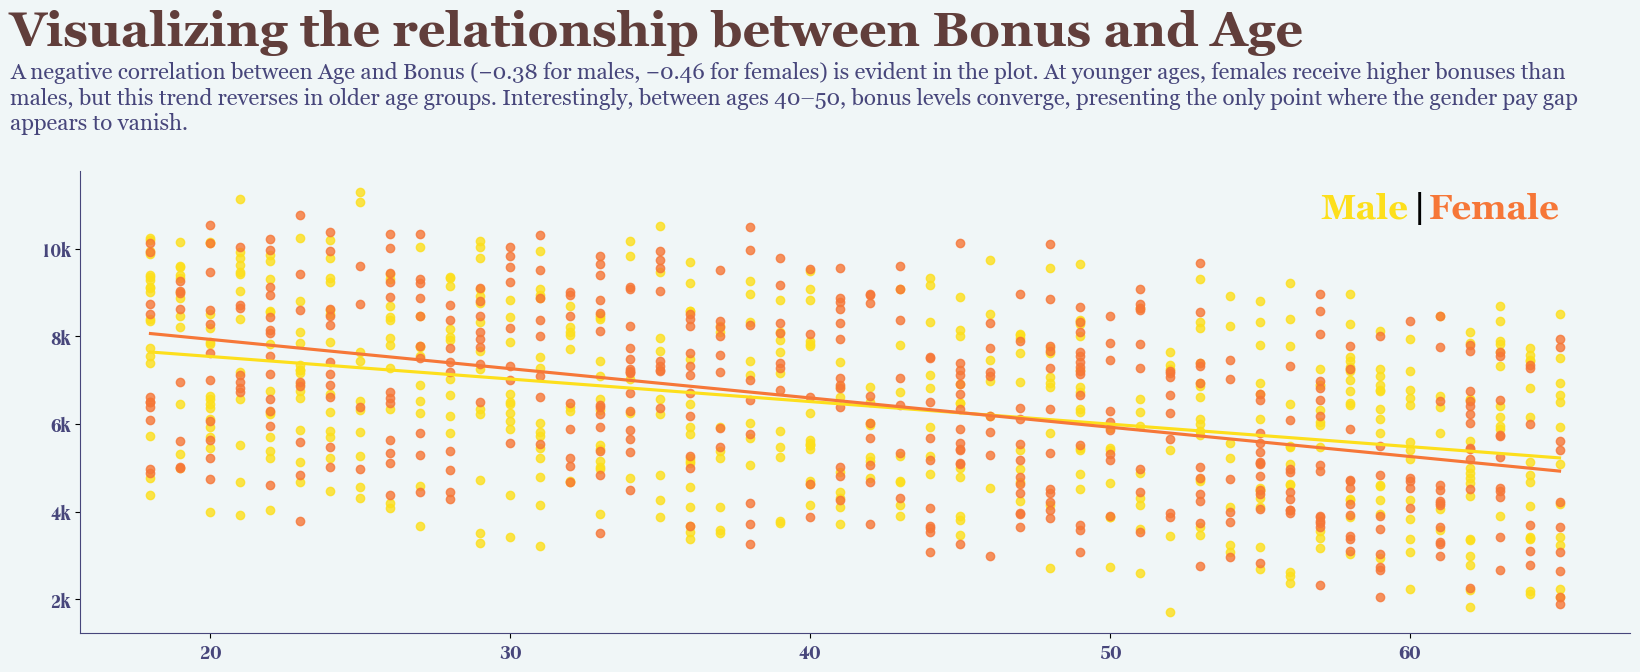

In [34]:
fig, ax = plt.subplots(figsize=(20, 6), facecolor=facecolor[0])
ax.patch.set_facecolor(facecolor[0])
fig.suptitle("Visualizing the relationship between Bonus and Age", 
             fontsize=35, color=accent[0], fontweight='bold', font=fonts[1],x=0.09,y=1.15,ha='left')
fig.text(0.09, 0.95,"""A negative correlation between Age and Bonus (−0.38 for males, −0.46 for females) is evident in the plot. At younger ages, females receive higher bonuses than
males, but this trend reverses in older age groups. Interestingly, between ages 40–50, bonus levels converge, presenting the only point where the gender pay gap 
appears to vanish.""", fontsize=16, ha='left',font=fonts[1], fontweight="medium",color=accent[1])
for gender, color in zip(['Male', 'Female'], [colors1[0], colors2[0]]):
    sns.regplot(data=df[df['Gender'] == gender],x='Age',y='Bonus',ax=ax,scatter=True,label=gender,color=color,ci=None)
ax.set_yticks([2000, 4000, 6000, 8000, 10000])
ax.set_yticklabels(["2k", "4k", "6k", "8k", "10k"],fontdict={'font': fonts[0], 'weight': 'bold','color':accent[1],'fontsize':14})
ax.set_xticklabels(ax.get_xticklabels(),fontdict={'font': fonts[0], 'weight': 'bold','color':accent[1],'fontsize':15})
ax.set_ylabel("")
ax.set_xlabel("")
add_title1(ax=ax, fontsize=25, x_vals=[0.8,0.86, 0.87], y=0.9,labels=["Male", "|", "Female"],colors=[colors1[0], "black", colors2[0]])
ax.legend().remove()
set_spines_color1(ax, accent[1])
ax.spines[['top', 'right']].set_visible(False)
plt.show()


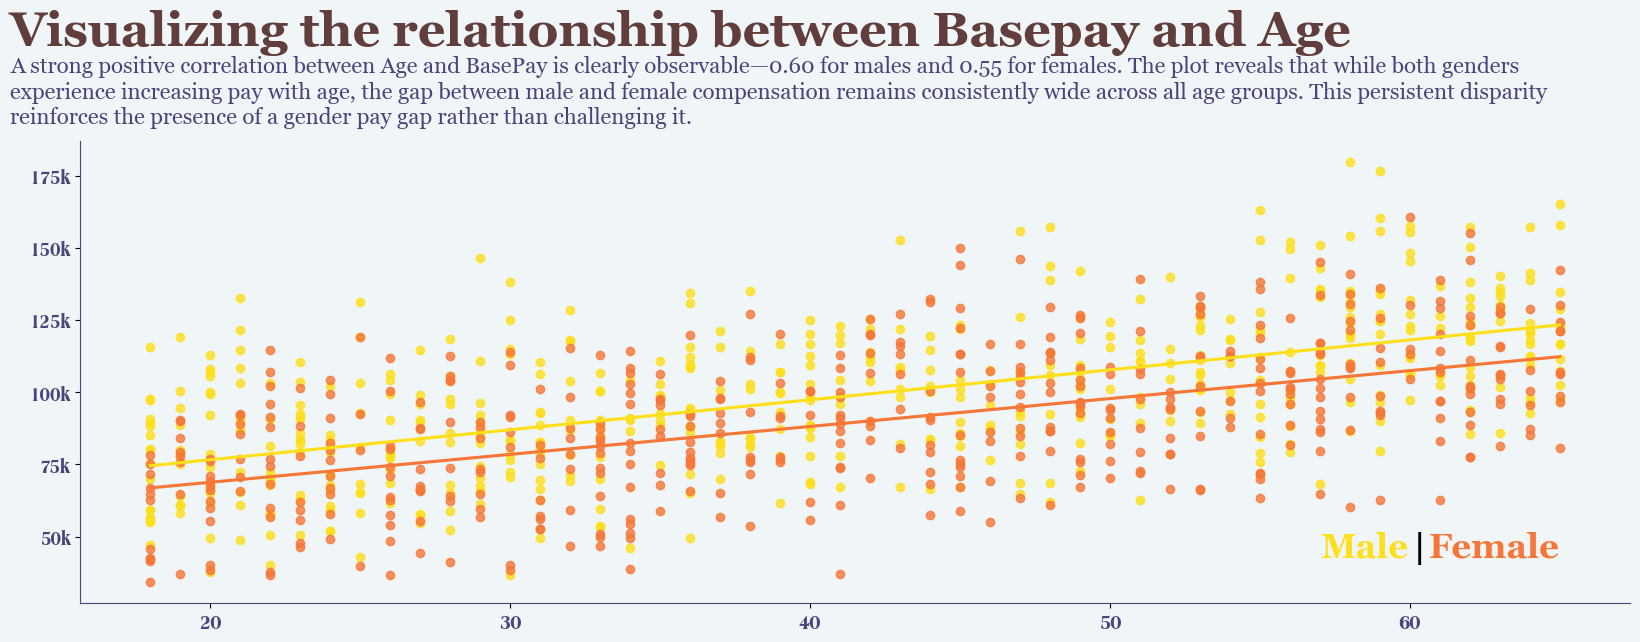

In [35]:
fig, ax = plt.subplots(figsize=(20, 6), facecolor=facecolor[0])
ax.patch.set_facecolor(facecolor[0])
fig.suptitle("Visualizing the relationship between Basepay and Age", 
             fontsize=35, color=accent[0], fontweight='bold', font=fonts[1],x=0.09,y=1.1,ha='left')
fig.text(0.09, 0.91,"""A strong positive correlation between Age and BasePay is clearly observable—0.60 for males and 0.55 for females. The plot reveals that while both genders 
experience increasing pay with age, the gap between male and female compensation remains consistently wide across all age groups. This persistent disparity
reinforces the presence of a gender pay gap rather than challenging it.""",
         fontsize=16, ha='left',font=fonts[1], fontweight="medium",color=accent[1])
for gender, color in zip(['Male', 'Female'], [colors1[0], colors2[0]]):
    sns.regplot(data=df[df['Gender'] == gender],x='Age',y='BasePay',ax=ax,scatter=True,label=gender,color=color,ci=None)
ax.set_yticks([50000, 75000, 100000, 125000, 150000, 175000])
ax.set_yticklabels(["50k", "75k", "100k", "125k", "150k", "175k"],fontdict={'font': fonts[0], 'weight': 'bold','color':accent[1],'fontsize':14})
ax.set_xticklabels(ax.get_xticklabels(),fontdict={'font': fonts[0], 'weight': 'bold','color':accent[1],'fontsize':15})
ax.set_ylabel("")
ax.set_xlabel("")
add_title1(ax=ax, fontsize=25, x_vals=[0.8,0.86, 0.87], y=0.1,labels=["Male", "|", "Female"],colors=[colors1[0], "black", colors2[0]])
ax.legend().remove()
set_spines_color1(ax, accent[1])
ax.spines[['top', 'right']].set_visible(False)
plt.show()
